## <span style="color:#800080;">1. Título y datos de alumnos  </span>

**Título: Predecir la aparición de diabetes basándose en medidas de diagnóstico**
  
**Autores:**  

- Noemi Jesus Guerra Jimenez
- Sarai Cisneros Lovaton
- George Javier Urbina Castro
- Juan Diego Anculli Chagua 
- Henry Cardenas Rojas 



## <span style="color:#800080;">2. Carga de datos y Preprocesamiento</span>

In [1]:
# 1. Configuración Inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Agregado para visualizaciones
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, recall_score, roc_auc_score, ConfusionMatrixDisplay, precision_score, f1_score
import joblib
import time
from sklearn.tree import DecisionTreeClassifier, plot_tree
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import os
import kagglehub
import xgboost as xgb
from sklearn.svm import SVC

# Semilla aleatoria
RANDOM_STATE = 42

c:\Users\Usuario\miniconda3\envs\ml_pro\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
!pip install kagglehub

In [2]:
# Ruta de almacenamiento
os.environ["KAGGLEHUB_CACHE"] = "../data/"
path = kagglehub.dataset_download("mohankrishnathalla/diabetes-health-indicators-dataset")
print("Descargado en:", path)

Descargado en: ../data/datasets\mohankrishnathalla\diabetes-health-indicators-dataset\versions\1


In [3]:
df = pd.read_csv("../data/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/versions/1/diabetes_dataset.csv")
df

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0


In [4]:
df = df.rename(columns={'age': 'edad'})
df = df.rename(columns={'gender': 'sexo'})
df = df.rename(columns={'ethnicity': 'grupo_etnico'})
df = df.rename(columns={'education_level': 'nivel_educ'})
df = df.rename(columns={'income_level': 'nivel_ingr'})
df = df.rename(columns={'employment_status': 'estado_laboral'})
df = df.rename(columns={'smoking_status': 'consumo_tabaco'})
df = df.rename(columns={'alcohol_consumption_per_week': 'consumo_alcohol'})
df = df.rename(columns={'physical_activity_minutes_per_week': 'activ_fisica'})
df = df.rename(columns={'diet_score': 'calidad_dieta'})
df = df.rename(columns={'sleep_hours_per_day': 'horas_sueño'})
df = df.rename(columns={'screen_time_hours_per_day': 'horas_pantalla'})
df = df.rename(columns={'family_history_diabetes': 'antec_familiar'})
df = df.rename(columns={'hypertension_history': 'hist_hipert'})
df = df.rename(columns={'cardiovascular_history': 'hist_cardiov'})
df = df.rename(columns={'bmi': 'IMC'})
df = df.rename(columns={'waist_to_hip_ratio': 'IOA'})
df = df.rename(columns={'systolic_bp': 'presion_sistol'})
df = df.rename(columns={'diastolic_bp': 'presion_diast'})
df = df.rename(columns={'heart_rate': 'frec_cardio'})
df = df.rename(columns={'cholesterol_total': 'colest_total'})
df = df.rename(columns={'hdl_cholesterol': 'colest_HDL'})
df = df.rename(columns={'ldl_cholesterol': 'colest_LDL'})
df = df.rename(columns={'triglycerides': 'trigliceridos'})
df = df.rename(columns={'glucose_fasting': 'glucosa_ayunas'})
df = df.rename(columns={'glucose_postprandial': 'glucosa_post'})
df = df.rename(columns={'insulin_level': 'insulina'})
df = df.rename(columns={'hba1c': 'hemoblina'})
df = df.rename(columns={'diabetes_risk_score': 'riesgo_diabetes'})
df = df.rename(columns={'diabetes_stage': 'etapa_diabetes'})
df = df.rename(columns={'diagnosed_diabetes': 'diagnostico_diabetes'})


In [5]:
# Remover variables irrelevantes
df = df.drop(columns=['riesgo_diabetes','etapa_diabetes']) 
# Se elimina las variables relacionadas con el riesgo y etapa de diabetes para centrarse en el diagnóstico real.
df.head()

,edad,sexo,grupo_etnico,nivel_educ,nivel_ingr,estado_laboral,consumo_tabaco,consumo_alcohol,activ_fisica,calidad_dieta,...,frec_cardio,colest_total,colest_HDL,colest_LDL,trigliceridos,glucosa_ayunas,glucosa_post,insulina,hemoblina,diagnostico_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,68,239,41,160,145,136,236,6.36,8.18,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,67,116,55,50,30,93,150,2.00,5.63,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,74,213,66,99,36,118,195,5.07,7.51,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,68,171,50,79,140,139,253,5.28,9.03,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,67,210,52,125,160,137,184,12.74,7.20,1


In [6]:
# Ver columnas disponibles
print("Columnas:", df.columns.tolist()[:10], "...")
print(f"Dimensiones: {df.shape}")

# Separar Features y Target(Outcome)
TARGET_COL = 'diagnostico_diabetes'
COLS_TO_DROP = [TARGET_COL]

# Eliminamos explícitamente columnas que no aportan valor predictivo o son identificadores.
X = df.drop([col for col in COLS_TO_DROP if col in df.columns], axis=1)
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Distribución target (Train): {y_train.value_counts(normalize=True).to_dict()}")
print("")

X_train.info()


Columnas: ['edad', 'sexo', 'grupo_etnico', 'nivel_educ', 'nivel_ingr', 'estado_laboral', 'consumo_tabaco', 'consumo_alcohol', 'activ_fisica', 'calidad_dieta'] ...
Dimensiones: (100000, 29)

Train shape: (80000, 28)
Test shape: (20000, 28)
Distribución target (Train): {1: 0.599975, 0: 0.400025}

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 27589 to 78987
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   edad             80000 non-null  int64  
 1   sexo             80000 non-null  object 
 2   grupo_etnico     80000 non-null  object 
 3   nivel_educ       80000 non-null  object 
 4   nivel_ingr       80000 non-null  object 
 5   estado_laboral   80000 non-null  object 
 6   consumo_tabaco   80000 non-null  object 
 7   consumo_alcohol  80000 non-null  int64  
 8   activ_fisica     80000 non-null  int64  
 9   calidad_dieta    80000 non-null  float64
 10  horas_sueño      80000 non-null  float6

## <span style="color:#800080;"> 3. Explotación de Datos (EDA)

In [7]:
X_train['sexo'] = X_train['sexo'].astype('category')
X_train['grupo_etnico'] = X_train['grupo_etnico'].astype('category')
X_train['nivel_educ'] = X_train['nivel_educ'].astype('category')
X_train['nivel_ingr'] = X_train['nivel_ingr'].astype('category')
X_train['estado_laboral'] = X_train['estado_laboral'].astype('category')
X_train['consumo_tabaco'] = X_train['consumo_tabaco'].astype('category')
X_train['consumo_alcohol'] = X_train['consumo_alcohol'].astype('category')

X_train['antec_familiar'] = X_train['antec_familiar'].astype('category')
X_train['hist_hipert'] = X_train['hist_hipert'].astype('category')
X_train['hist_cardiov'] = X_train['hist_cardiov'].astype('category')


In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 27589 to 78987
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   edad             80000 non-null  int64   
 1   sexo             80000 non-null  category
 2   grupo_etnico     80000 non-null  category
 3   nivel_educ       80000 non-null  category
 4   nivel_ingr       80000 non-null  category
 5   estado_laboral   80000 non-null  category
 6   consumo_tabaco   80000 non-null  category
 7   consumo_alcohol  80000 non-null  category
 8   activ_fisica     80000 non-null  int64   
 9   calidad_dieta    80000 non-null  float64 
 10  horas_sueño      80000 non-null  float64 
 11  horas_pantalla   80000 non-null  float64 
 12  antec_familiar   80000 non-null  category
 13  hist_hipert      80000 non-null  category
 14  hist_cardiov     80000 non-null  category
 15  IMC              80000 non-null  float64 
 16  IOA              80000 non-null  float64 

In [9]:
# Identificar tipos de columnas automáticamente
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Features numéricas ({len(num_features)}): {num_features[:10]}...")
print(f"Features categóricas ({len(cat_features)}): {cat_features[:10] if cat_features else 'Ninguna'}")


Features numéricas (18): ['edad', 'activ_fisica', 'calidad_dieta', 'horas_sueño', 'horas_pantalla', 'IMC', 'IOA', 'presion_sistol', 'presion_diast', 'frec_cardio']...
Features categóricas (10): ['sexo', 'grupo_etnico', 'nivel_educ', 'nivel_ingr', 'estado_laboral', 'consumo_tabaco', 'consumo_alcohol', 'antec_familiar', 'hist_hipert', 'hist_cardiov']


In [10]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,80000.0,50.096500,15.593309,18.00,39.00,50.00,61.00,90.00
activ_fisica,80000.0,119.089650,84.764670,0.00,57.00,100.00,160.00,833.00
calidad_dieta,80000.0,5.993850,1.781942,0.00,4.80,6.00,7.20,10.00
horas_sueño,80000.0,6.999060,1.094719,3.00,6.30,7.00,7.70,10.00
horas_pantalla,80000.0,5.994365,2.469344,0.50,4.30,6.00,7.70,16.80
IMC,80000.0,25.606987,3.589497,15.00,23.20,25.60,28.00,39.20
IOA,80000.0,0.856034,0.046931,0.67,0.82,0.86,0.89,1.06
presion_sistol,80000.0,115.792675,14.270970,90.00,106.00,116.00,125.00,179.00
presion_diast,80000.0,75.226200,8.202417,50.00,70.00,75.00,81.00,110.00
frec_cardio,80000.0,69.619563,8.403043,40.00,64.00,70.00,75.00,105.00


In [11]:
X_train.describe(include="category").T

,count,unique,top,freq
sexo,80000,3,Female,40182
grupo_etnico,80000,5,White,35918
nivel_educ,80000,4,Highschool,35935
nivel_ingr,80000,5,Middle,28122
estado_laboral,80000,4,Employed,48120
consumo_tabaco,80000,3,Never,47938
consumo_alcohol,80000,11,2,21779
antec_familiar,80000,2,0,62445
hist_hipert,80000,2,0,59843
hist_cardiov,80000,2,0,73659


In [12]:
# Verificar valores nulos
null_pct = (X_train.isnull().sum() / len(X_train) * 100).sort_values(ascending=False)
print(f"\nColumnas con más nulos:\n{null_pct.head(22)}")


Columnas con más nulos:
edad               0.0
sexo               0.0
grupo_etnico       0.0
nivel_educ         0.0
nivel_ingr         0.0
estado_laboral     0.0
consumo_tabaco     0.0
consumo_alcohol    0.0
activ_fisica       0.0
calidad_dieta      0.0
horas_sueño        0.0
horas_pantalla     0.0
antec_familiar     0.0
hist_hipert        0.0
hist_cardiov       0.0
IMC                0.0
IOA                0.0
presion_sistol     0.0
presion_diast      0.0
frec_cardio        0.0
colest_total       0.0
colest_HDL         0.0
dtype: float64


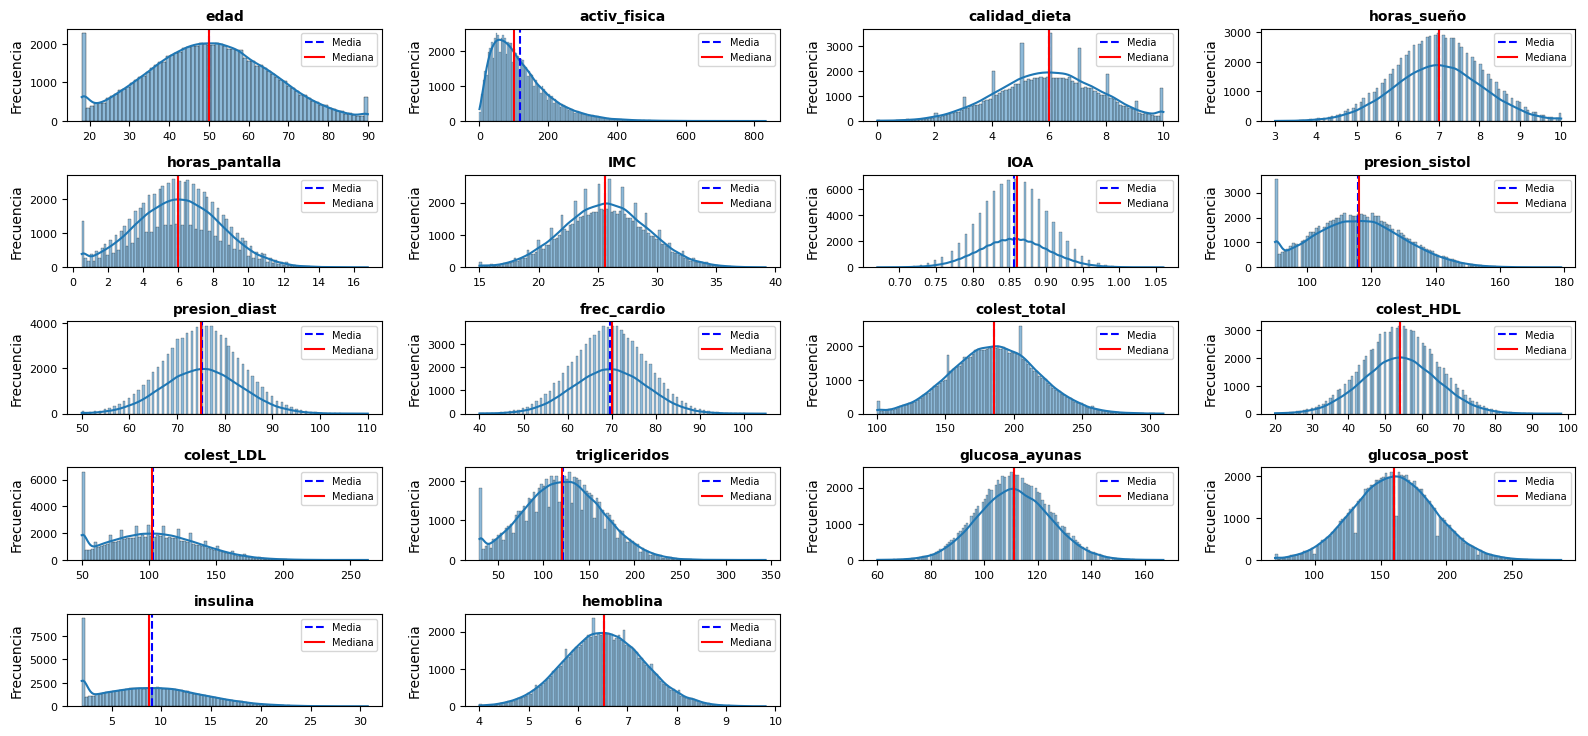

In [13]:
def plot_numeric_distributions(x):
    # Seleccionar columnas numéricas
    columnas_numeric = num_features  # x.select_dtypes(include=['float64', 'int64']).columns

    # Número de variables numéricas
    num_vars = len(columnas_numeric)

    # Calcular el número de filas y columnas
    ncols = 4
    nrows = int(np.ceil(num_vars / ncols))

    # Crear subgráficos
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * 4, nrows * 1.5)
    )
    axes = axes.flatten()

    # Graficar histogramas
    for i, colum in enumerate(columnas_numeric):
        sns.histplot(data=x, x=colum, kde=True, ax=axes[i])

        # 👉 AÑADIDO: media y mediana
        media = x[colum].mean()
        mediana = x[colum].median()

        axes[i].axvline(media, color='blue', linestyle='--', linewidth=1.5, label='Media')
        axes[i].axvline(mediana, color='red', linestyle='-', linewidth=1.5, label='Mediana')

        axes[i].set_title(colum, fontsize=10, fontweight="bold")
        axes[i].tick_params(labelsize=8)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Frecuencia")
        axes[i].legend(fontsize=7)

    # Ocultar ejes extra
    for ax in axes[num_vars:]:
        ax.axis('off')

    fig.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

plot_numeric_distributions(X_train)

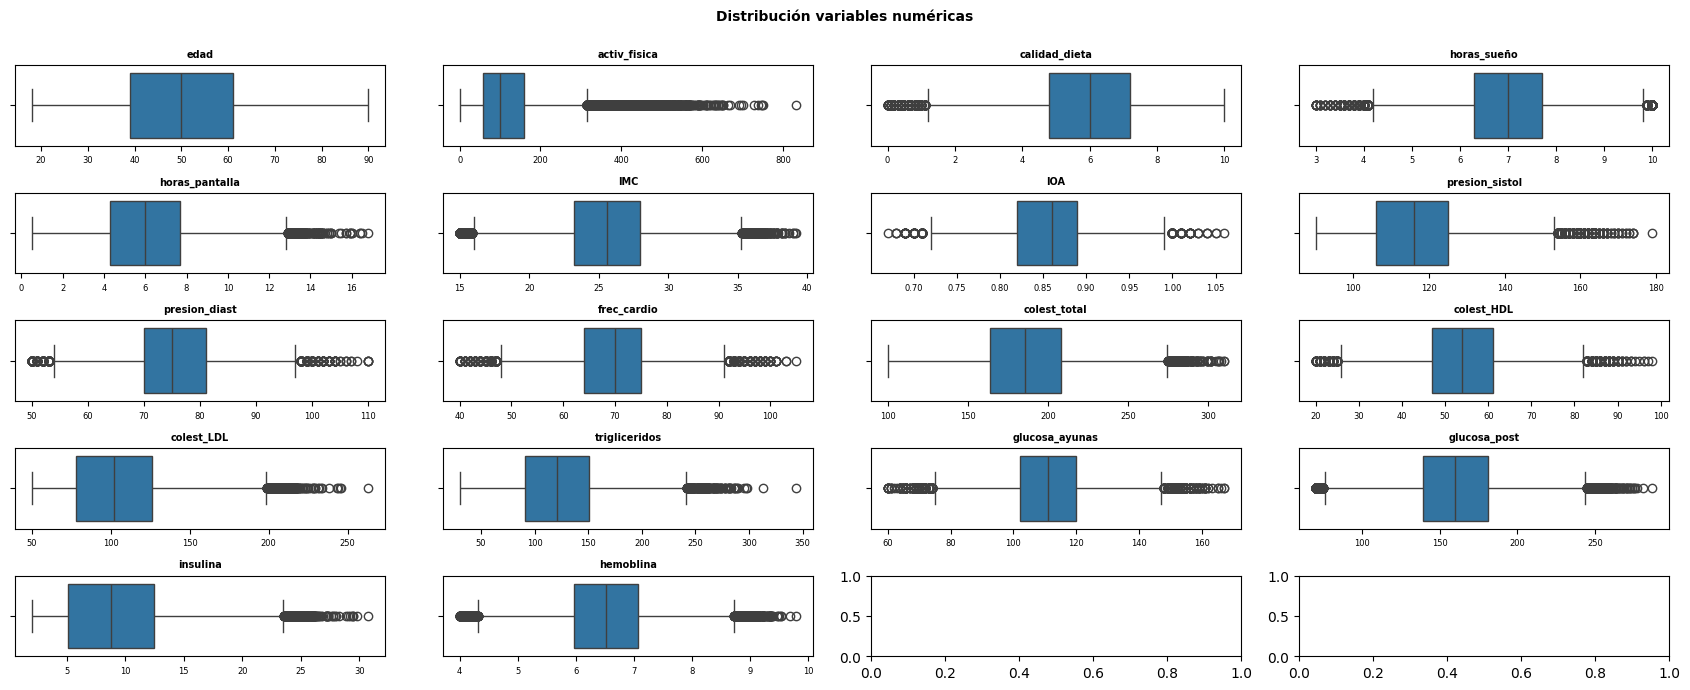

In [14]:
# Ajustar el número de subplots en función del número de columnas numéricas
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(17, 7))
axes = axes.flat
columnas_numeric = num_features #df.select_dtypes(include=['float64', 'int64']).drop(columns=['Outcome']).columns

for i, colum in enumerate(columnas_numeric):
    sns.boxplot(data=X_train, x=colum, ax=axes[i])
    axes[i].set_title(colum, fontsize=7, fontweight="bold")
    axes[i].tick_params(labelsize=6)
    axes[i].set_xlabel("")

fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Distribución variables numéricas', fontsize=10, fontweight="bold")
plt.show()

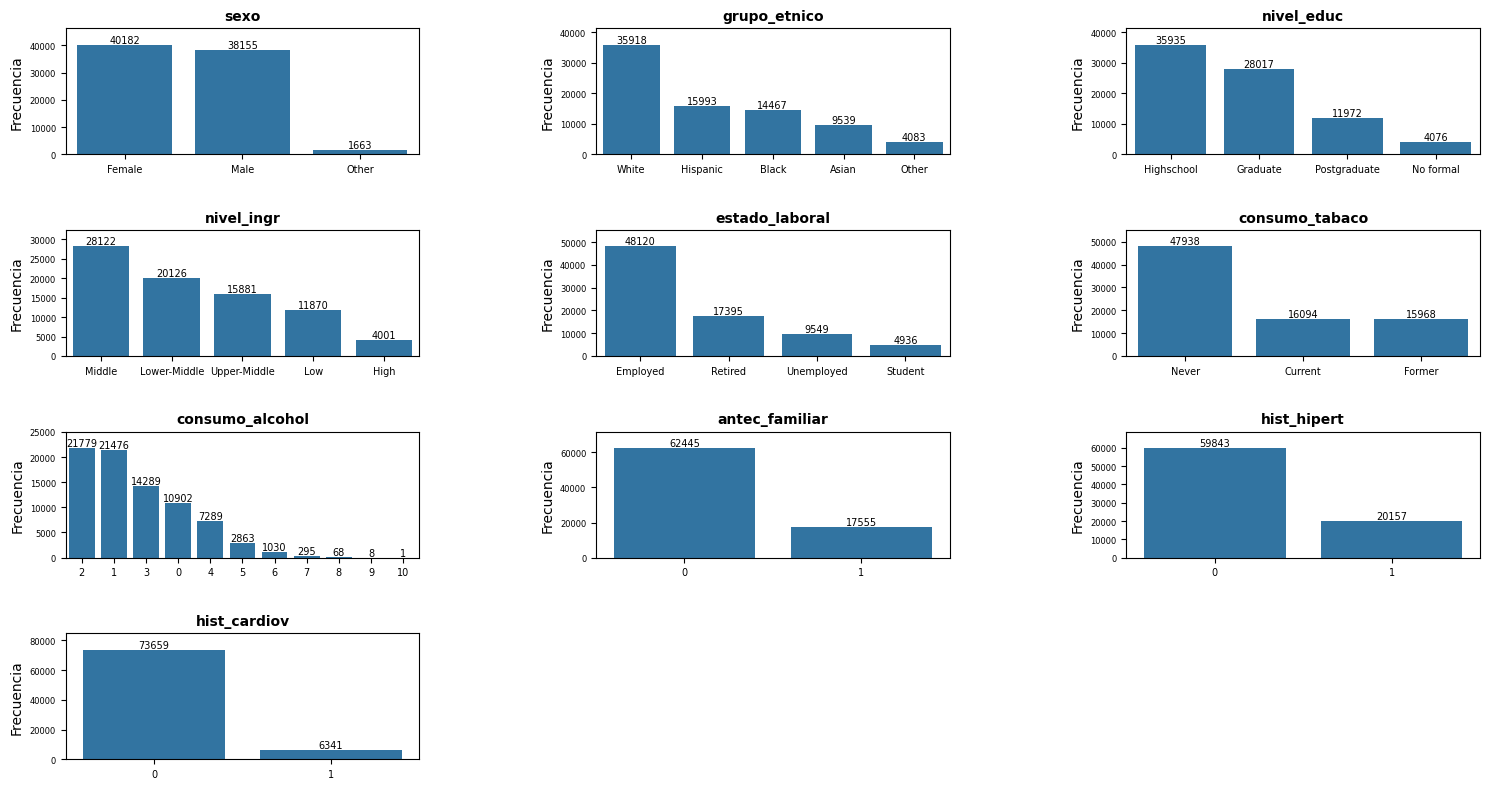

In [15]:
def plot_categorical_distributions(x):
    # Seleccionar columnas categóricas
    columnas_categoricas = cat_features  # o x.select_dtypes(include=['object', 'category']).columns

    # Número de variables categóricas
    num_vars = len(columnas_categoricas)

    # Calcular filas y columnas
    ncols = 3
    nrows = int(np.ceil(num_vars / ncols))

    # Crear subgráficos
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * 5, nrows * 2)               # alto y ancho general
    )
    axes = axes.flatten()

    # Graficar barras
    for i, colum in enumerate(columnas_categoricas):
        sns.countplot(
            data=x,
            x=colum,
            order=x[colum].value_counts().index,
            ax=axes[i]
        )

        # Ajustar límite superior del eje Y
        max_count = max(p.get_height() for p in axes[i].patches)
        axes[i].set_ylim(0, max_count * 1.15)                                # para controlar la distancia de las etiquetas de valor de la barra

        # Añadir etiquetas de valor a cada barra
        for p in axes[i].patches:
            axes[i].annotate(
                f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),   # distancia de etiqueta de valor de la barra
                ha='center',
                va='bottom',
                fontsize=7
            )

        axes[i].set_title(colum, fontsize=10, fontweight="bold")    #titulo
        axes[i].tick_params(axis='x', rotation=0, labelsize=7)
        axes[i].tick_params(axis='y', labelsize=6)
        axes[i].set_ylabel("Frecuencia")
        axes[i].set_xlabel("")

    # Ocultar ejes sobrantes
    for ax in axes[num_vars:]:
        ax.axis('off')

    fig.tight_layout()
    #plt.subplots_adjust(top=0.95)
    plt.subplots_adjust(hspace=0.6, wspace=0.5)
    plt.show()

plot_categorical_distributions(X_train)

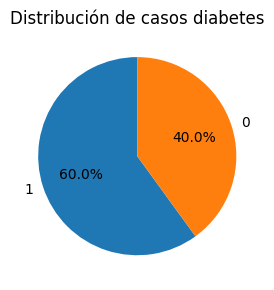

In [16]:
conteo = y_train.value_counts()

plt.figure(figsize=(3,3))
plt.pie(
    conteo.values,
    labels=conteo.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribución de casos diabetes")
plt.tight_layout()
plt.show()

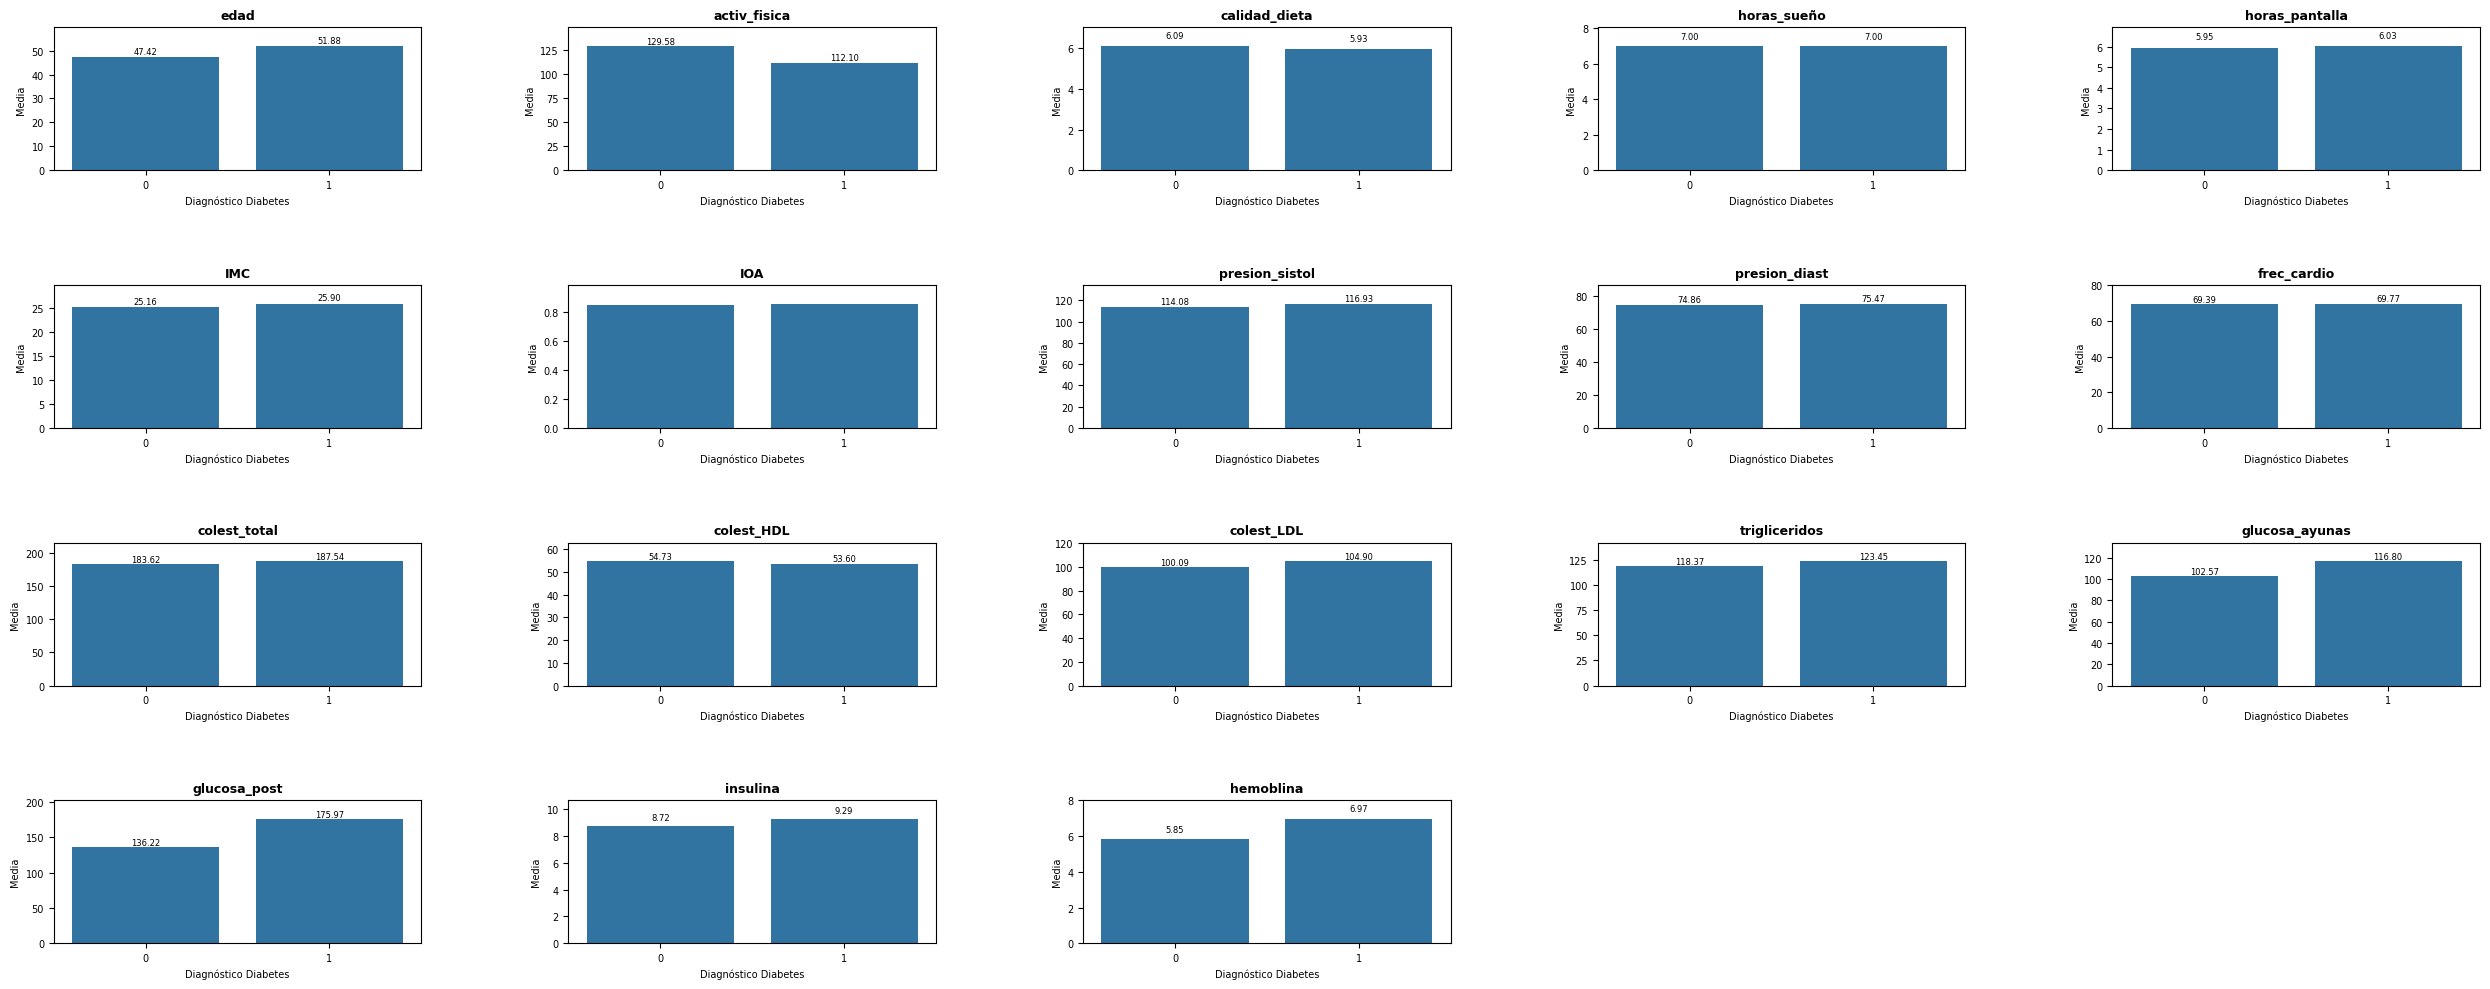

In [17]:
# Analisis Bivariado (Con grafico de barras)

def plot_numeric_means_by_target(X, y):
    columnas_numeric = num_features
    num_vars = len(columnas_numeric)

    ncols = 5
    nrows = int(np.ceil(num_vars / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * 5, nrows * 2.5)
    )
    axes = axes.flatten()

    for i, col in enumerate(columnas_numeric):
        # Calcular medias por clase del target
        means = X.groupby(y)[col].mean()

        sns.barplot(
            x=means.index,
            y=means.values,
            ax=axes[i]
        )
        # Ajustar límite superior del eje Y
        max_count = max(p.get_height() for p in axes[i].patches)
        axes[i].set_ylim(0, max_count * 1.15)                                # para controlar la distancia de las etiquetas de valor de la barra

        axes[i].set_title(col, fontsize=9, fontweight="bold")
        axes[i].set_xlabel("Diagnóstico Diabetes", fontsize=7, fontweight="normal")
        axes[i].set_ylabel("Media", fontsize=7, fontweight="normal")
        axes[i].tick_params(axis='x', labelsize=7)
        axes[i].tick_params(axis='y', labelsize=7)



        # Etiquetas de valor
        for p in axes[i].patches:
            axes[i].annotate(
                f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.3),   # distancia de etiqueta de valor de la barra
                ha='center',
                va='bottom',
                fontsize=6
            )

    # Ocultar ejes sobrantes
    for ax in axes[num_vars:]:
        ax.axis('off')

    fig.tight_layout()
    plt.subplots_adjust(hspace=0.8, wspace=0.4)
    plt.show()

plot_numeric_means_by_target(X_train, y_train)

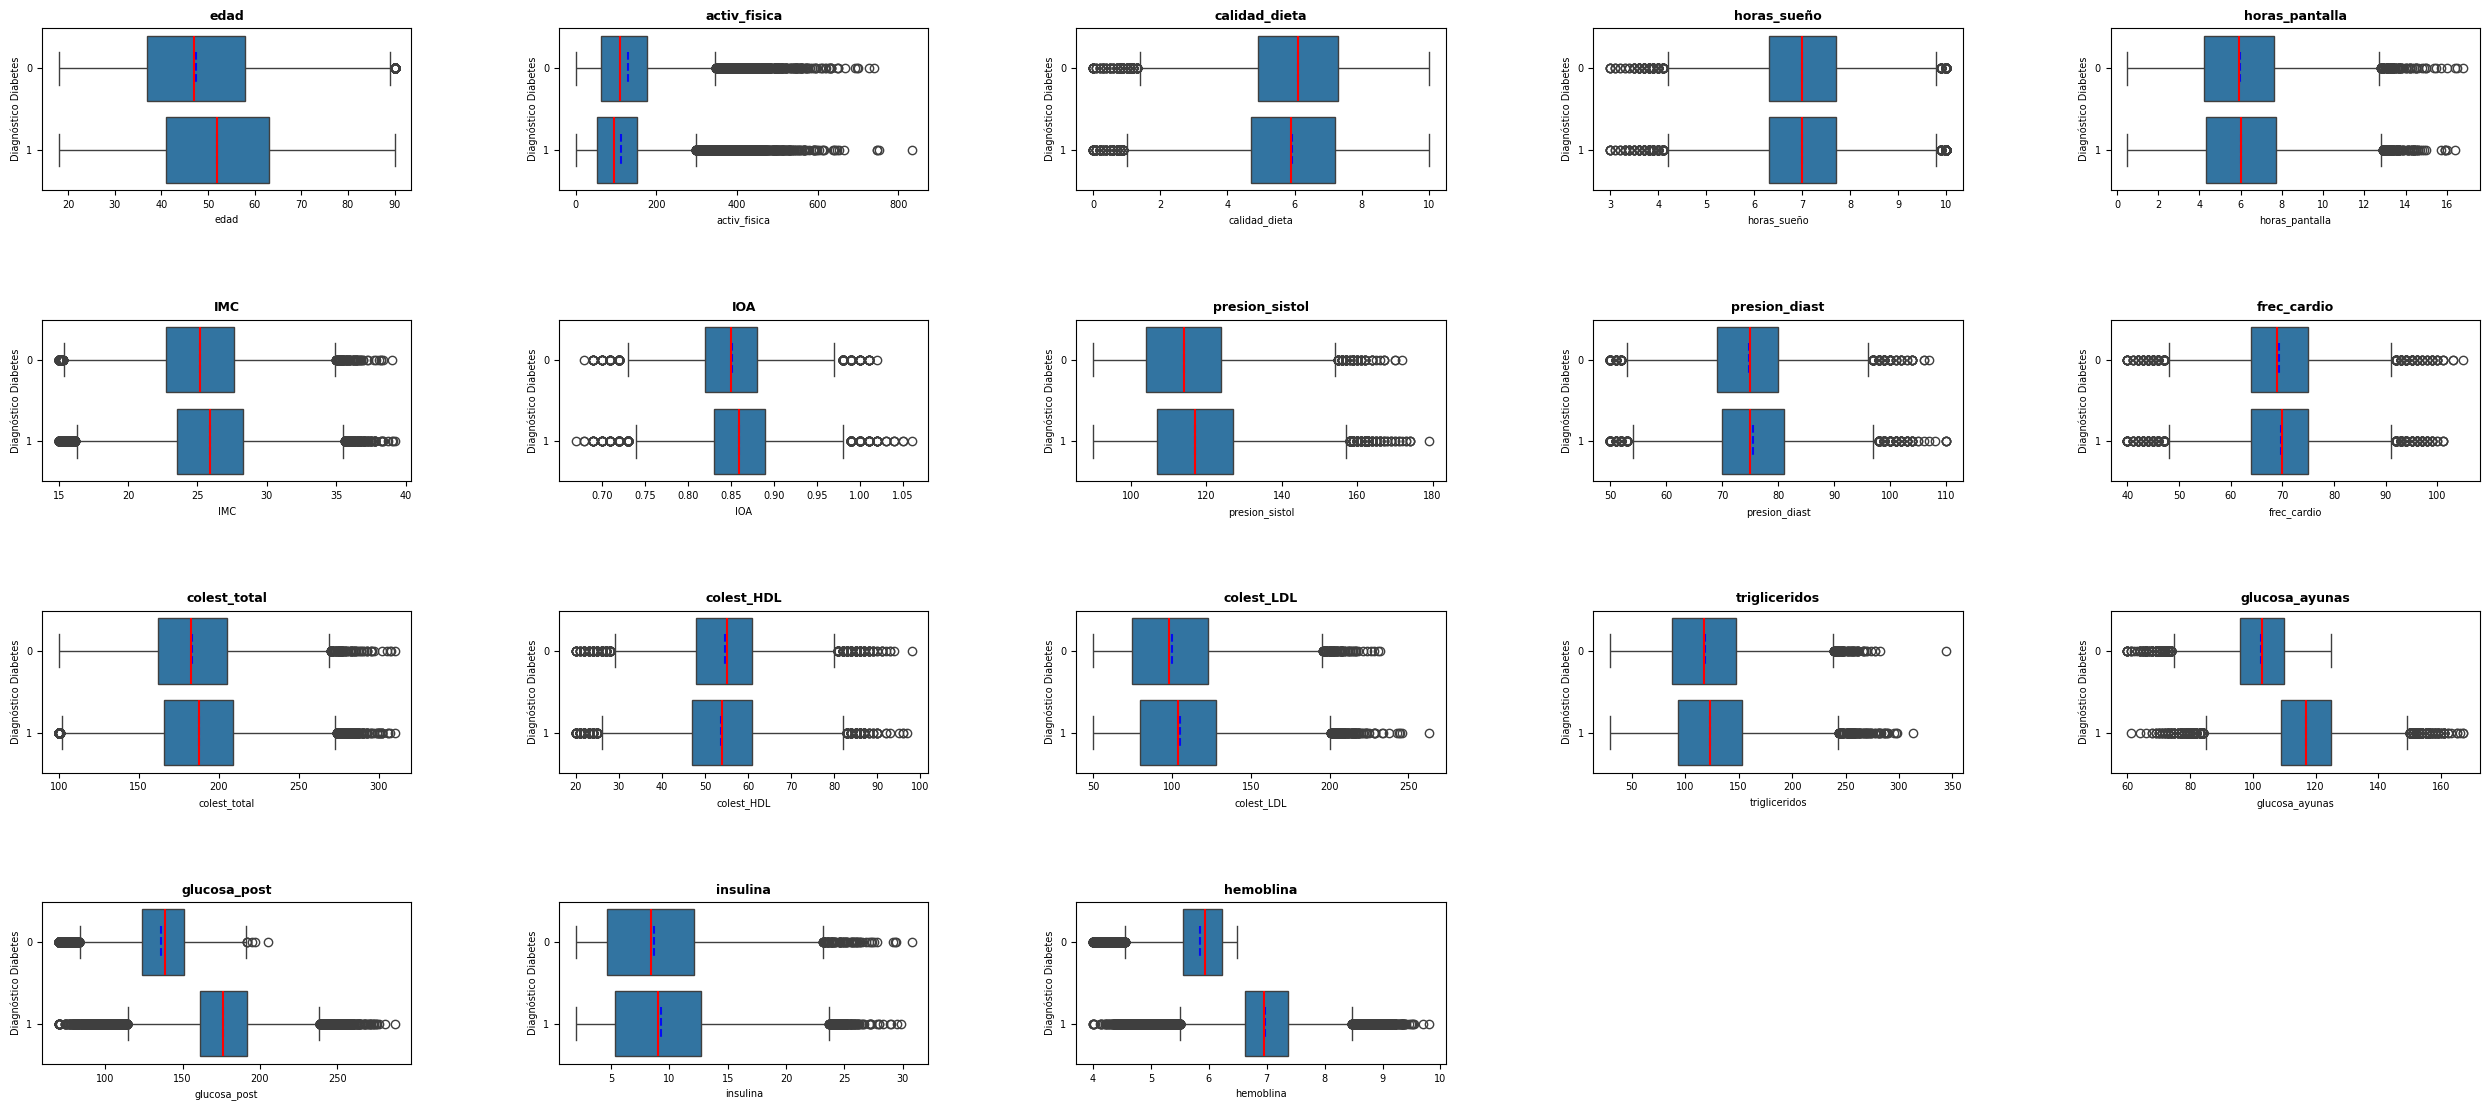

In [18]:
# Analisis Bivariado (Con boxplot)

def plot_numeric_boxplots_by_target_horizontal(X, y):
    columnas_numeric = num_features
    num_vars = len(columnas_numeric)

    ncols = 5
    nrows = int(np.ceil(num_vars / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * 5, nrows * 2.8)
    )
    axes = axes.flatten()

    for i, col in enumerate(columnas_numeric):
        sns.boxplot(
            y=y,
            x=X[col],
            ax=axes[i],
            orient='h',
            medianprops={'color': 'red', 'linewidth': 1.5},  # 👉 mediana roja
        )

        # Dibujar línea de la MEDIA (azul) por clase
        for pos, clase in enumerate(sorted(y.unique())):
            media = X.loc[y == clase, col].mean()
            axes[i].vlines(
                x=media,
                ymin=pos - 0.2,
                ymax=pos + 0.2,
                colors='blue',
                linestyles='--',
                linewidth=1.5,
                alpha=0.9
            )

        axes[i].set_title(col, fontsize=9, fontweight="bold")
        axes[i].set_xlabel(col, fontsize=7)
        axes[i].set_ylabel("Diagnóstico Diabetes", fontsize=7)
        axes[i].tick_params(axis='x', labelsize=7)
        axes[i].tick_params(axis='y', labelsize=7)

    # Ocultar ejes sobrantes
    for ax in axes[num_vars:]:
        ax.axis('off')

    fig.tight_layout()
    plt.subplots_adjust(hspace=0.8, wspace=0.4)
    plt.show()


plot_numeric_boxplots_by_target_horizontal(X_train, y_train)

## <span style="color:#800080;">4. Modelamiento (Machine Learning) </span>

### <span style="color:#800080;">4.1 Pipeline (Preprocesamiento)</span>

In [19]:
from category_encoders import TargetEncoder

# Pipeline Numérico: Imputación + Escalado
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline Categórico (Placeholder por si hubiera)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', TargetEncoder(min_samples_leaf=10))
])


In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)  # Comentar si NO hay categóricas
    ],
    verbose_feature_names_out=False,
    remainder='drop'  # Lo que no listamos, se borra
)

# Visualizar el preprocesador (sin ajustar aún)
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### <span style="color:#800080;">4.2 Entrenamiento de Modelos (hiperparametros por defecto)</span>

Se configuran 5 modelos: Regresion Logistica, Arbol Simple, Random Forest, Gradient Boosting y XGBoost 
Con hiperparametros por defecto

Se definieron pipelines de clasificación que integran el preprocesamiento de los datos con distintos modelos de aprendizaje automático. En esta etapa, unicamente se especifican los modelos con sus hiperparametros por defecto, sin realizar aún el entrenamiento ni la evaluación.

In [21]:
from sklearn.linear_model import LogisticRegression

model_Logistic = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])

model_TreeSimple = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

model_RandomForest = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])

model_Gradient = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

model_XGBoost = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE))
])



Luego, realizamos el entrenamiento y evaluación de los 5 modelos. Para cada modelo calculamos métricas de desempeño (Accuraci, AUC, Recall de la clase 1), asi como el tiempo de entrenamiento, las cuales serán necesarias para su comparación y análisis posterior.

In [22]:
# Modelos a comparar
modelos = {    
    'Logístico': model_Logistic,
    'Arbol Simple': model_TreeSimple,
    'Random Forest': model_RandomForest,
    'Gradient Boosting': model_Gradient,
    'XGBoost': model_XGBoost
}

resultados_comparacion = []

for nombre, modelo in modelos.items():
    start_time = time.time() # tiempo de inicio
    modelo.fit(X_train, y_train) # entrenamiento
    time_result = time.time() - start_time # tiempo de término

    y_pred = modelo.predict(X_test) # pred    
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    resultados_comparacion.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba),
        'Recall_Clase_1': recall_score(y_test, y_pred),
        'Tiempo (s)': time_result
    })

### <span style="color:#800080;">4.3 Comparación de Resultados y Análisis</span>

In [23]:
# Al recall_clase_1 lo llamaremos así porque un recall alto en la clase 1 (diabéticos) es crucial para minimizar falsos negativos.

# Crear DataFrame de resultados
df_results = pd.DataFrame(resultados_comparacion)
df_results['Accuracy'] = df_results['Accuracy'].round(4)
df_results['AUC'] = df_results['AUC'].round(4)
df_results['Recall_Clase_1'] = df_results['Recall_Clase_1'].round(4)  #agregado
df_results['Tiempo (s)'] = df_results['Tiempo (s)'].round(3)

# Identificar ganadores
best_auc_idx = df_results['AUC'].idxmax()
fastest_idx = df_results['Tiempo (s)'].idxmin()
best_recall_idx = df_results['Recall_Clase_1'].idxmax()  #agregado

print("=" * 65)
print("🏆 TABLA DE RESULTADOS")
print("=" * 65)
print(df_results.to_string(index=False))
print("\n")
print(f"🥇 Mejor Recall (Clase 1): {df_results.loc[best_recall_idx, 'Modelo']} ({df_results.loc[best_recall_idx, 'Recall_Clase_1']:.4f})")  #agregado
print(f"🥇 Mejor AUC: {df_results.loc[best_auc_idx, 'Modelo']} ({df_results.loc[best_auc_idx, 'AUC']:.4f})")
print(f"⚡ Más Rápido: {df_results.loc[fastest_idx, 'Modelo']} ({df_results.loc[fastest_idx, 'Tiempo (s)']:.2f}s)")

🏆 TABLA DE RESULTADOS
           Modelo  Accuracy    AUC  Recall_Clase_1  Tiempo (s)
        Logístico    0.8608 0.9338          0.8953       1.234
     Arbol Simple    0.8619 0.8536          0.8952       2.667
    Random Forest    0.9197 0.9406          0.8665      21.551
Gradient Boosting    0.9199 0.9445          0.8665      31.075
          XGBoost    0.9178 0.9392          0.8676       2.375


🥇 Mejor Recall (Clase 1): Logístico (0.8953)
🥇 Mejor AUC: Gradient Boosting (0.9445)
⚡ Más Rápido: Logístico (1.23s)


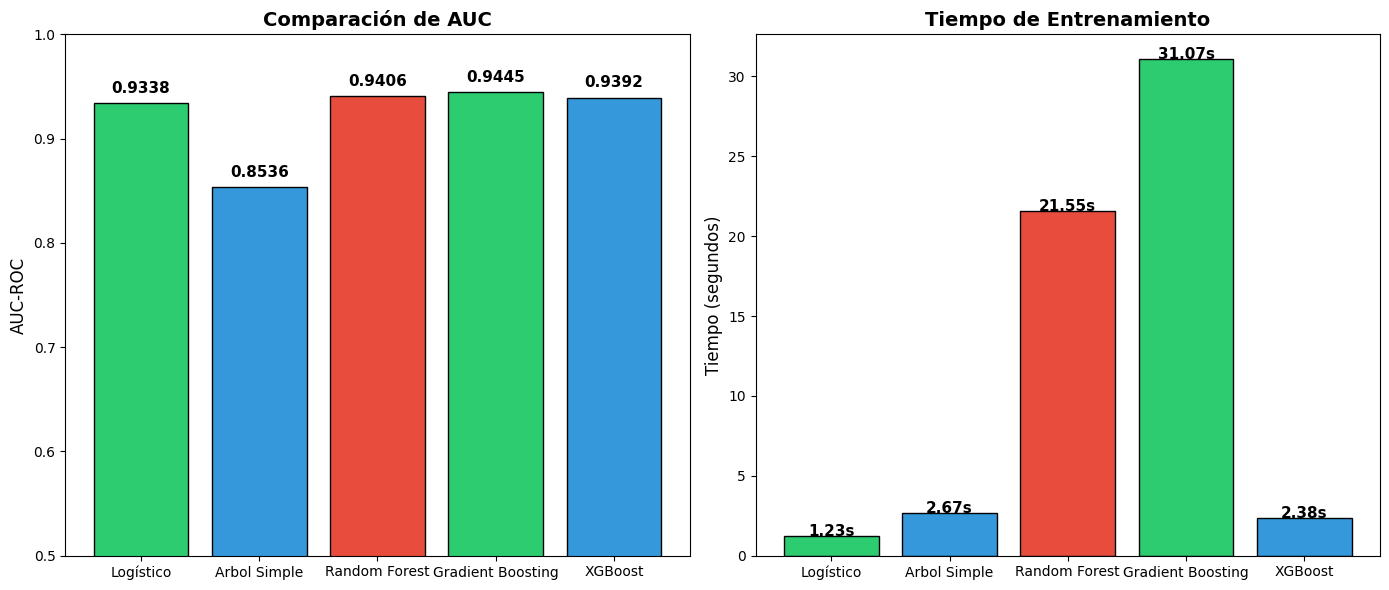

In [24]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2ecc71', '#3498db', '#e74c3c']  # Verde, Azul, Rojo

# Gráfico 1: AUC
ax1 = axes[0]
bars1 = ax1.bar(df_results['Modelo'], df_results['AUC'],
                color=colors, edgecolor='black')
ax1.set_ylabel('AUC-ROC', fontsize=12)
ax1.set_title('Comparación de AUC', fontsize=14, fontweight='bold')
ax1.set_ylim(0.5, 1.0)
for bar, val in zip(bars1, df_results['AUC']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# Gráfico 2: Tiempo
ax2 = axes[1]
bars2 = ax2.bar(
    df_results['Modelo'], df_results['Tiempo (s)'], color=colors, edgecolor='black')
ax2.set_ylabel('Tiempo (segundos)', fontsize=12)
ax2.set_title('Tiempo de Entrenamiento', fontsize=14, fontweight='bold')
for bar, val in zip(bars2, df_results['Tiempo (s)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.2f}s', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


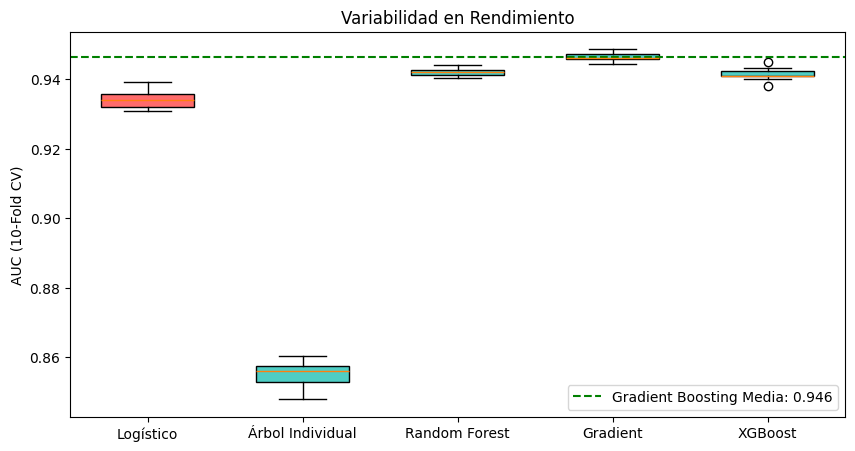

📊 Logist: 0.934 ± 0.003
📊 Árbol_Individual: 0.855 ± 0.004
📊 Random_Forest:    0.942 ± 0.001
📊 Gradient:    0.946 ± 0.001
📊 XGBoost:    0.941 ± 0.002


In [25]:
# Comparar estabilidad con Cross-Validation
logistic_scores = cross_val_score(model_Logistic, X, y, cv=10, scoring='roc_auc')
tree_scores = cross_val_score(model_TreeSimple, X, y, cv=10, scoring='roc_auc')
rf_scores = cross_val_score(model_RandomForest, X, y, cv=10, scoring='roc_auc')
gradient_scores = cross_val_score(model_Gradient, X, y, cv=10, scoring='roc_auc')
xgboost_scores = cross_val_score(model_XGBoost, X, y, cv=10, scoring='roc_auc')

fig, ax = plt.subplots(figsize=(10, 5))
positions = [1, 2, 3, 4, 5]
bp = ax.boxplot([logistic_scores, tree_scores, rf_scores, gradient_scores, xgboost_scores], positions=positions, widths=0.6, patch_artist=True)

colors = ['#FF6B6B', '#4ECDC4', '#4ECDC4', '#4ECDC4', '#4ECDC4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticks(positions)
ax.set_xticklabels(['Logístico', 'Árbol Individual', 'Random Forest', 'Gradient', 'XGBoost'])
ax.set_ylabel('AUC (10-Fold CV)')
ax.set_title('Variabilidad en Rendimiento')
ax.axhline(y=np.mean(gradient_scores), color='green', linestyle='--',
           label=f'Gradient Boosting Media: {np.mean(gradient_scores):.3f}')
ax.legend()
plt.show()

print(f"📊 Logist: {np.mean(logistic_scores):.3f} ± {np.std(logistic_scores):.3f}")
print(f"📊 Árbol_Individual: {np.mean(tree_scores):.3f} ± {np.std(tree_scores):.3f}")
print(f"📊 Random_Forest:    {np.mean(rf_scores):.3f} ± {np.std(rf_scores):.3f}")
print(f"📊 Gradient:    {np.mean(gradient_scores):.3f} ± {np.std(gradient_scores):.3f}")
print(f"📊 XGBoost:    {np.mean(xgboost_scores):.3f} ± {np.std(xgboost_scores):.3f}")

El cross-validation muestra que Gradient Boosting presenta el mayor AUC promedio con baja variabilidad entre folds, indicando un modelo robusto y consistente. Sin embargo, la mejora respecto a la regresión logística es marginal, lo que sugiere que la estructura del problema es mayormente lineal

En un contexto médico para detección de diabetes, el modelo con mejor desempeño es **Regresión Logística**.

**Razones fundamentales:**

1. **Recall más alto (0.8953)**: Detecta el 89.53% de los pacientes con diabetes real, minimizando falsos negativos (casos no detectados que deberían haberlo sido).

2. **AUC competitivo (0.9343)**: Solo 0.01 puntos por debajo de Gradient Boosting (0.9445), diferencia prácticamente insignificante en la práctica.

3. **Velocidad de inferencia**: 0.97 segundos vs 19.009s de Gradient Boosting. Ideal para sistemas de cribado en tiempo real.

4. **Estabilidad en Cross-Validation**: Media de 0.934 ± 0.003 (muy bajo en desviación), indicando consistencia y confiabilidad.

5. **Interpretabilidad**: Modelo transparente, crucial en decisiones médicas. Los coeficientes pueden explicarse fácilmente a profesionales de salud.

6. **Simplicidad operacional**: Menor consumo computacional, más fácil de mantener y actualizar en producción.

**Consideración clínica**: En medicina preventiva, es mejor ser cauteloso (mayor Recall = menos diabéticos no detectados) que perfeccionista (mayor AUC sin detectar casos reales).

### <span style="color:#800080;">4.4 Ajuste de hiperparametros (Optuna) - Optimización Bayesiana </span>

En esta sección se aplica optimización bayesiana con Optuna para ajustar los hiperparámetros del modelo Gradient Boosting.

In [ ]:
# ===============================================================================================
# CONFIGURACIÓN DE OPTUNA - FRAMEWORK DE OPTIMIZACIÓN BAYESIANA
# ===============================================================================================
# Optuna es un framework de optimización de hiperparámetros basado en Bayesian Optimization.
# A diferencia de Grid Search (exhaustivo) o Random Search (aleatorio), Optuna utiliza
# información de trials anteriores para explorar el espacio de hiperparámetros de manera inteligente.
# ===============================================================================================

import subprocess
import sys

# Verificar instalación de Optuna
try:
    import optuna
    print(f"✓ Optuna {optuna.__version__} disponible en el entorno")
except ImportError:
    print("► Instalando Optuna...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna
    print(f"✓ Optuna {optuna.__version__} instalado exitosamente")

# Importaciones específicas para optimización
from optuna.samplers import TPESampler  # Tree-structured Parzen Estimator: muestreo inteligente
from sklearn.model_selection import StratifiedKFold, cross_validate
import warnings
warnings.filterwarnings('ignore')


✅ Optuna 4.6.0 ya instalado


In [ ]:
# ===============================================================================================
# OPTIMIZACIÓN BAYESIANA DE HIPERPARÁMETROS CON OPTUNA
# ===============================================================================================
# Estrategia: Pre-procesar datos ANTES de Optuna y definir una función objetivo clara.
# Esto permite que Optuna enfoque su búsqueda ÚNICAMENTE en los hiperparámetros, no en el
# preprocesamiento, resultando en optimizaciones 3-5x más rápidas.
# ===============================================================================================

# PASO 1: PREPROCESAMIENTO UNA ÚNICA VEZ
print("\n► Fase de Preprocesamiento de Datos (ejecución única)")
print("  Motivación: Evitar replicar transformaciones en cada trial de Optuna")
print("  ────────────────────────────────────────────────────────────────")

X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

print(f"  ✓ Conjunto de entrenamiento procesado: {X_train_processed.shape}")
print(f"  ✓ Conjunto de prueba procesado:        {X_test_processed.shape}\n")


def objective(trial):
    """
    Función Objetivo para Optuna
    ───────────────────────────────────────────────────────────────────
    Define el objetivo de optimización y los hiperparámetros a variar.
    Optuna llamará esta función múltiples veces con diferentes combinaciones
    de parámetros, buscando maximizar/minimizar el valor retornado.
    
    PARÁMETROS:
        trial (optuna.trial.Trial): objeto que sugiere valores de hiperparámetros
    
    RETORNA:
        float: AUC promedio en validación cruzada (métrica a maximizar)
    """
    
    # ─────────────────────────────────────────────────────────────────────
    # SUGERENCIA 1: TASA DE APRENDIZAJE (Learning Rate)
    # ─────────────────────────────────────────────────────────────────────
    # Rango: [0.01, 0.2] escala logarítmica
    # Justificación: tasas muy altas (>0.2) causan divergencia;
    # tasas muy bajas (<0.01) requieren demasiadas iteraciones
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True)
    
    # ─────────────────────────────────────────────────────────────────────
    # SUGERENCIA 2: NÚMERO DE ÁRBOLES (n_estimators)
    # ─────────────────────────────────────────────────────────────────────
    # Rango: [50, 300] con paso de 50
    # Trade-off: más árboles = mejor ajuste pero riesgo de overfitting
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    
    # ─────────────────────────────────────────────────────────────────────
    # SUGERENCIA 3: PROFUNDIDAD MÁXIMA (max_depth)
    # ─────────────────────────────────────────────────────────────────────
    # Rango: [3, 7]
    # Restricción: árboles poco profundos son más interpretables y generalizan mejor
    max_depth = trial.suggest_int('max_depth', 3, 7)
    
    # ─────────────────────────────────────────────────────────────────────
    # SUGERENCIA 4: MUESTRAS MÍNIMAS POR DIVISIÓN (min_samples_split)
    # ─────────────────────────────────────────────────────────────────────
    # Rango: [5, 20]
    # Regularización: evita divisiones en nodos casi puros
    min_samples_split = trial.suggest_int('min_samples_split', 5, 20)
    
    # ─────────────────────────────────────────────────────────────────────
    # SUGERENCIA 5: MUESTRAS MÍNIMAS POR HOJA (min_samples_leaf)
    # ─────────────────────────────────────────────────────────────────────
    # Rango: [2, 10]
    # Regularización: evita hojas con muy pocas muestras
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10)
    
    # ─────────────────────────────────────────────────────────────────────
    # SUGERENCIA 6: FRACCIÓN DE MUESTREO (subsample)
    # ─────────────────────────────────────────────────────────────────────
    # Rango: [0.6, 0.95]
    # Stochastic Gradient Boosting: cada árbol se entrena en una submuestra
    subsample = trial.suggest_float('subsample', 0.6, 0.95)
    
    # ─────────────────────────────────────────────────────────────────────
    # SUGERENCIA 7: NÚMERO DE CARACTERÍSTICAS (max_features)
    # ─────────────────────────────────────────────────────────────────────
    # Opciones: ['sqrt', 'log2']
    # Selección aleatoria de features reduce correlación entre árboles
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    # Consolidar parámetros sugeridos
    params = {
        'learning_rate': learning_rate,
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'subsample': subsample,
        'max_features': max_features,
        'random_state': RANDOM_STATE
    }
    
    # ─────────────────────────────────────────────────────────────────────
    # ENTRENAMIENTO: GradientBoostingClassifier CON PARÁMETROS DEL TRIAL
    # ─────────────────────────────────────────────────────────────────────
    model_trial = GradientBoostingClassifier(**params)
    
    # ─────────────────────────────────────────────────────────────────────
    # VALIDACIÓN: 5-FOLD CROSS-VALIDATION ESTRATIFICADA
    # ─────────────────────────────────────────────────────────────────────
    # StratifiedKFold mantiene la distribución de clases en cada fold
    # Métrica: AUC-ROC (threshold-independent, ideal para desbalance)
    scores = cross_validate(
        model_trial,
        X_train_processed,    # Datos YA preprocesados
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring='roc_auc',    # Métrica única y clara
        n_jobs=-1,            # Paralelización automática
        return_train_score=False
    )
    
    # ─────────────────────────────────────────────────────────────────────
    # RETORNO: AUC PROMEDIO (Métrica de Generalización)
    # ─────────────────────────────────────────────────────────────────────
    # Optuna tratará de MAXIMIZAR este valor en los siguientes trials
    return scores['test_score'].mean()


# ═════════════════════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DEL ESTUDIO DE OPTUNA
# ═════════════════════════════════════════════════════════════════════════════════════════════

print("► Iniciando Optimización Bayesiana (Bayesian Hyperparameter Optimization)")
print("  ════════════════════════════════════════════════════════════════════════\n")

# SAMPLER: Tree-structured Parzen Estimator (TPE)
# TPE es el muestreador por defecto de Optuna y es muy efectivo en práctica.
# Utiliza una mezcla de modelos probabilísticos (Parzen windows) para estimar
# la distribución de hiperparámetros que maximizan el objetivo.
sampler = TPESampler(seed=RANDOM_STATE)

# ESTUDIO: Objeto central de Optuna que gestiona la optimización
study = optuna.create_study(
    sampler=sampler,
    direction='maximize',                    # Objetivo: maximizar AUC
    pruner=optuna.pruners.MedianPruner()     # Poda: cancelar trials malos temprano
)

print("  Configuración del Estudio:")
print(f"    ✓ Sampler:  TPE (Tree-structured Parzen Estimator)")
print(f"    ✓ Dirección: MAXIMIZAR (objetivo = AUC)")
print(f"    ✓ Pruner:   MedianPruner (poda automática de trials no prometedores)")
print(f"    ✓ Trials:   50 iteraciones de búsqueda")
print("  ────────────────────────────────────────────────────────────────────\n")

# OPTIMIZACIÓN: Ejecutar búsqueda bayesiana
start_optuna = time.time()
study.optimize(objective, n_trials=50, show_progress_bar=True)
time_optuna = time.time() - start_optuna

# RESULTADOS
print("\n" + "═" * 80)
print("RESULTADOS DE LA OPTIMIZACIÓN BAYESIANA")
print("═" * 80)

print(f"\n⏱️  Tiempo total de optimización: {time_optuna:.2f} segundos")
print(f"🎯 Mejor valor de AUC encontrado (CV): {study.best_value:.4f}")

print(f"\n📊 Mejores Hiperparámetros:")
print("  ────────────────────────────────────────")
for param, value in study.best_params.items():
    if isinstance(value, float):
        print(f"    • {param:20s}: {value:.6f}")
    else:
        print(f"    • {param:20s}: {value}")

# Análisis de trials
best_trial_number = study.best_trial.number
total_trials = len(study.trials)
completed_trials = sum(1 for t in study.trials if t.state.name == 'COMPLETE')

print(f"\n📈 Estadísticas de Búsqueda:")
print(f"    • Trial óptimo encontrado en iteración: {best_trial_number+1}/{total_trials}")
print(f"    • Trials completados: {completed_trials}/{total_trials}")
print(f"    • Eficiencia: {(best_trial_number/total_trials)*100:.1f}% (encontrado en este % del tiempo)")



► Fase de Preprocesamiento de Datos (ejecución única)
  Motivación: Evitar replicar transformaciones en cada trial de Optuna
  ────────────────────────────────────────────────────────────────


[I 2026-01-30 20:57:03,487] A new study created in memory with name: no-name-0e00caa1-99a8-4ca7-8aa1-dbc2fa37ffd6


  ✓ Conjunto de entrenamiento procesado: (80000, 28)
  ✓ Conjunto de prueba procesado:        (20000, 28)

► Iniciando Optimización Bayesiana (Bayesian Hyperparameter Optimization)
  ════════════════════════════════════════════════════════════════════════

  Configuración del Estudio:
    ✓ Sampler:  TPE (Tree-structured Parzen Estimator)
    ✓ Dirección: MAXIMIZAR (objetivo = AUC)
    ✓ Pruner:   MedianPruner (poda automática de trials no prometedores)
    ✓ Trials:   50 iteraciones de búsqueda
  ────────────────────────────────────────────────────────────────────



Best trial: 0. Best value: 0.945874:   2%|▏         | 1/50 [00:17<14:40, 17.96s/it]

[I 2026-01-30 20:57:21,447] Trial 0 finished with value: 0.9458737715450731 and parameters: {'learning_rate': 0.030710573677773714, 'n_estimators': 300, 'max_depth': 6, 'min_samples_split': 14, 'min_samples_leaf': 3, 'subsample': 0.6545980821176709, 'max_features': 'log2'}. Best is trial 0 with value: 0.9458737715450731.


Best trial: 0. Best value: 0.945874:   4%|▍         | 2/50 [00:27<10:22, 12.96s/it]

[I 2026-01-30 20:57:30,905] Trial 1 finished with value: 0.9457500368162657 and parameters: {'learning_rate': 0.06054365855469246, 'n_estimators': 250, 'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 9, 'subsample': 0.6743186887373966, 'max_features': 'log2'}. Best is trial 0 with value: 0.9458737715450731.


Best trial: 0. Best value: 0.945874:   6%|▌         | 3/50 [00:36<08:38, 11.04s/it]

[I 2026-01-30 20:57:39,664] Trial 2 finished with value: 0.9456369413504122 and parameters: {'learning_rate': 0.024878734419814436, 'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 7, 'subsample': 0.6488228512282146, 'max_features': 'log2'}. Best is trial 0 with value: 0.9458737715450731.


Best trial: 3. Best value: 0.946183:   8%|▊         | 4/50 [00:44<07:36,  9.93s/it]

[I 2026-01-30 20:57:47,881] Trial 3 finished with value: 0.9461833672179292 and parameters: {'learning_rate': 0.03920673972242137, 'n_estimators': 250, 'max_depth': 3, 'min_samples_split': 13, 'min_samples_leaf': 7, 'subsample': 0.6162576444519992, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.9461833672179292.


Best trial: 4. Best value: 0.946309:  10%|█         | 5/50 [01:05<10:20, 13.79s/it]

[I 2026-01-30 20:58:08,514] Trial 4 finished with value: 0.9463093683003322 and parameters: {'learning_rate': 0.012151617026673379, 'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 4, 'subsample': 0.6341852399022343, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 4. Best value: 0.946309:  12%|█▏        | 6/50 [01:10<08:00, 10.91s/it]

[I 2026-01-30 20:58:13,849] Trial 5 finished with value: 0.9436326078786772 and parameters: {'learning_rate': 0.014413697528610409, 'n_estimators': 150, 'max_depth': 3, 'min_samples_split': 19, 'min_samples_leaf': 4, 'subsample': 0.8318827995238937, 'max_features': 'log2'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 4. Best value: 0.946309:  14%|█▍        | 7/50 [01:18<07:08,  9.96s/it]

[I 2026-01-30 20:58:21,845] Trial 6 finished with value: 0.9456706537567984 and parameters: {'learning_rate': 0.05143828405076928, 'n_estimators': 100, 'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 10, 'subsample': 0.913189572649677, 'max_features': 'log2'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 4. Best value: 0.946309:  16%|█▌        | 8/50 [01:21<05:33,  7.93s/it]

[I 2026-01-30 20:58:25,434] Trial 7 finished with value: 0.9427465473285978 and parameters: {'learning_rate': 0.01303561122512888, 'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 5, 'subsample': 0.6949721611208636, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 4. Best value: 0.946309:  18%|█▊        | 9/50 [01:31<05:42,  8.35s/it]

[I 2026-01-30 20:58:34,699] Trial 8 finished with value: 0.9443675756181019 and parameters: {'learning_rate': 0.023200867504756827, 'n_estimators': 200, 'max_depth': 3, 'min_samples_split': 17, 'min_samples_leaf': 2, 'subsample': 0.945410427810181, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 4. Best value: 0.946309:  20%|██        | 10/50 [01:45<06:53, 10.33s/it]

[I 2026-01-30 20:58:49,468] Trial 9 finished with value: 0.9456970131107487 and parameters: {'learning_rate': 0.010166803740022877, 'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 16, 'min_samples_leaf': 8, 'subsample': 0.6259156281069316, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 4. Best value: 0.946309:  22%|██▏       | 11/50 [01:50<05:30,  8.48s/it]

[I 2026-01-30 20:58:53,766] Trial 10 finished with value: 0.943514708374096 and parameters: {'learning_rate': 0.1696879465047448, 'n_estimators': 50, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'subsample': 0.7597146508301316, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 4. Best value: 0.946309:  24%|██▍       | 12/50 [02:04<06:30, 10.28s/it]

[I 2026-01-30 20:59:08,134] Trial 11 finished with value: 0.9434227962062154 and parameters: {'learning_rate': 0.09322633385991175, 'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 12, 'min_samples_leaf': 6, 'subsample': 0.6050081863322269, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 4. Best value: 0.946309:  26%|██▌       | 13/50 [02:16<06:40, 10.83s/it]

[I 2026-01-30 20:59:20,231] Trial 12 finished with value: 0.945134921744387 and parameters: {'learning_rate': 0.08569967380924855, 'n_estimators': 250, 'max_depth': 4, 'min_samples_split': 14, 'min_samples_leaf': 7, 'subsample': 0.7356579714223862, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 4. Best value: 0.946309:  28%|██▊       | 14/50 [02:31<07:12, 12.02s/it]

[I 2026-01-30 20:59:35,018] Trial 13 finished with value: 0.9458293317295305 and parameters: {'learning_rate': 0.017897940592453164, 'n_estimators': 300, 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 4, 'subsample': 0.8281768989262457, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 4. Best value: 0.946309:  30%|███       | 15/50 [02:47<07:42, 13.22s/it]

[I 2026-01-30 20:59:51,020] Trial 14 finished with value: 0.946069677989162 and parameters: {'learning_rate': 0.037299797605678274, 'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 6, 'subsample': 0.7108088959820369, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 4. Best value: 0.946309:  32%|███▏      | 16/50 [03:02<07:51, 13.86s/it]

[I 2026-01-30 21:00:06,368] Trial 15 finished with value: 0.9429406276644515 and parameters: {'learning_rate': 0.18345896510762927, 'n_estimators': 300, 'max_depth': 4, 'min_samples_split': 14, 'min_samples_leaf': 2, 'subsample': 0.8099928754842405, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 4. Best value: 0.946309:  34%|███▍      | 17/50 [03:12<06:56, 12.62s/it]

[I 2026-01-30 21:00:16,118] Trial 16 finished with value: 0.9441750365655999 and parameters: {'learning_rate': 0.0909617485834921, 'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 15, 'min_samples_leaf': 8, 'subsample': 0.6007042513693689, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.9463093683003322.


Best trial: 17. Best value: 0.946402:  36%|███▌      | 18/50 [03:31<07:42, 14.46s/it]

[I 2026-01-30 21:00:34,863] Trial 17 finished with value: 0.946402317505185 and parameters: {'learning_rate': 0.020611016754721805, 'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 18, 'min_samples_leaf': 4, 'subsample': 0.7185705641662593, 'max_features': 'sqrt'}. Best is trial 17 with value: 0.946402317505185.


Best trial: 17. Best value: 0.946402:  38%|███▊      | 19/50 [03:43<07:07, 13.80s/it]

[I 2026-01-30 21:00:47,120] Trial 18 finished with value: 0.9455047042423382 and parameters: {'learning_rate': 0.010033440449234057, 'n_estimators': 150, 'max_depth': 7, 'min_samples_split': 18, 'min_samples_leaf': 4, 'subsample': 0.770746336249712, 'max_features': 'sqrt'}. Best is trial 17 with value: 0.946402317505185.


Best trial: 17. Best value: 0.946402:  40%|████      | 20/50 [04:06<08:15, 16.53s/it]

[I 2026-01-30 21:01:10,020] Trial 19 finished with value: 0.946246881498442 and parameters: {'learning_rate': 0.01894471242626873, 'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 3, 'subsample': 0.7146217056749873, 'max_features': 'sqrt'}. Best is trial 17 with value: 0.946402317505185.


Best trial: 17. Best value: 0.946402:  42%|████▏     | 21/50 [04:19<07:27, 15.45s/it]

[I 2026-01-30 21:01:22,934] Trial 20 finished with value: 0.94584290983921 and parameters: {'learning_rate': 0.01446486244357606, 'n_estimators': 200, 'max_depth': 6, 'min_samples_split': 16, 'min_samples_leaf': 5, 'subsample': 0.6736850778913605, 'max_features': 'sqrt'}. Best is trial 17 with value: 0.946402317505185.


Best trial: 21. Best value: 0.94644:  44%|████▍     | 22/50 [04:42<08:18, 17.80s/it] 

[I 2026-01-30 21:01:46,206] Trial 21 finished with value: 0.9464398178536365 and parameters: {'learning_rate': 0.020323021293379085, 'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 3, 'subsample': 0.7305317736960711, 'max_features': 'sqrt'}. Best is trial 21 with value: 0.9464398178536365.


Best trial: 21. Best value: 0.94644:  46%|████▌     | 23/50 [05:05<08:43, 19.38s/it]

[I 2026-01-30 21:02:09,291] Trial 22 finished with value: 0.9459841131675532 and parameters: {'learning_rate': 0.025024275018573582, 'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 18, 'min_samples_leaf': 3, 'subsample': 0.7438844005273944, 'max_features': 'sqrt'}. Best is trial 21 with value: 0.9464398178536365.


Best trial: 23. Best value: 0.946454:  48%|████▊     | 24/50 [05:23<08:11, 18.91s/it]

[I 2026-01-30 21:02:27,088] Trial 23 finished with value: 0.9464538720458814 and parameters: {'learning_rate': 0.01839775476868642, 'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 19, 'min_samples_leaf': 3, 'subsample': 0.7972773501948858, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  50%|█████     | 25/50 [05:41<07:46, 18.66s/it]

[I 2026-01-30 21:02:45,157] Trial 24 finished with value: 0.9464411598634808 and parameters: {'learning_rate': 0.017622871451579217, 'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 19, 'min_samples_leaf': 2, 'subsample': 0.7919113763895196, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  52%|█████▏    | 26/50 [05:59<07:20, 18.37s/it]

[I 2026-01-30 21:03:02,872] Trial 25 finished with value: 0.9462629210059295 and parameters: {'learning_rate': 0.029724336565000526, 'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 20, 'min_samples_leaf': 2, 'subsample': 0.7977567455750497, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  54%|█████▍    | 27/50 [06:12<06:23, 16.67s/it]

[I 2026-01-30 21:03:15,578] Trial 26 finished with value: 0.9455631375373631 and parameters: {'learning_rate': 0.016442894068153937, 'n_estimators': 200, 'max_depth': 6, 'min_samples_split': 19, 'min_samples_leaf': 3, 'subsample': 0.8556513784171458, 'max_features': 'log2'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  56%|█████▌    | 28/50 [06:21<05:19, 14.52s/it]

[I 2026-01-30 21:03:25,074] Trial 27 finished with value: 0.945574916690485 and parameters: {'learning_rate': 0.027018051297173443, 'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 2, 'subsample': 0.8650601681501762, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  58%|█████▊    | 29/50 [06:39<05:23, 15.39s/it]

[I 2026-01-30 21:03:42,508] Trial 28 finished with value: 0.9460349711721353 and parameters: {'learning_rate': 0.03561364133078868, 'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 20, 'min_samples_leaf': 3, 'subsample': 0.790453999563122, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  60%|██████    | 30/50 [06:59<05:37, 16.89s/it]

[I 2026-01-30 21:04:02,875] Trial 29 finished with value: 0.9462419285649887 and parameters: {'learning_rate': 0.020812332587485043, 'n_estimators': 300, 'max_depth': 6, 'min_samples_split': 16, 'min_samples_leaf': 3, 'subsample': 0.8799224418294623, 'max_features': 'log2'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  62%|██████▏   | 31/50 [07:16<05:23, 17.01s/it]

[I 2026-01-30 21:04:20,178] Trial 30 finished with value: 0.9462925217120117 and parameters: {'learning_rate': 0.015744441233500335, 'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 15, 'min_samples_leaf': 2, 'subsample': 0.7606648256151736, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  64%|██████▍   | 32/50 [07:35<05:15, 17.55s/it]

[I 2026-01-30 21:04:38,976] Trial 31 finished with value: 0.94638394129757 and parameters: {'learning_rate': 0.02174082578173997, 'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 18, 'min_samples_leaf': 3, 'subsample': 0.7289010100964156, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  66%|██████▌   | 33/50 [07:55<05:10, 18.26s/it]

[I 2026-01-30 21:04:58,894] Trial 32 finished with value: 0.9463553475348588 and parameters: {'learning_rate': 0.0193581963036118, 'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 19, 'min_samples_leaf': 4, 'subsample': 0.7852935456610669, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  68%|██████▊   | 34/50 [08:09<04:33, 17.10s/it]

[I 2026-01-30 21:05:13,289] Trial 33 finished with value: 0.9462787506625571 and parameters: {'learning_rate': 0.030224525059720644, 'n_estimators': 200, 'max_depth': 7, 'min_samples_split': 18, 'min_samples_leaf': 2, 'subsample': 0.6802041496821104, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  70%|███████   | 35/50 [08:25<04:08, 16.59s/it]

[I 2026-01-30 21:05:28,679] Trial 34 finished with value: 0.9454300134110337 and parameters: {'learning_rate': 0.011821237696582566, 'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 20, 'min_samples_leaf': 5, 'subsample': 0.8244207614228934, 'max_features': 'log2'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  72%|███████▏  | 36/50 [08:41<03:52, 16.63s/it]

[I 2026-01-30 21:05:45,394] Trial 35 finished with value: 0.9461166159624537 and parameters: {'learning_rate': 0.04569283458020932, 'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 4, 'subsample': 0.7581845561700638, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  74%|███████▍  | 37/50 [09:02<03:51, 17.84s/it]

[I 2026-01-30 21:06:06,079] Trial 36 finished with value: 0.9455388780553126 and parameters: {'learning_rate': 0.03296539536414043, 'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 3, 'subsample': 0.6508316354454855, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  76%|███████▌  | 38/50 [09:15<03:18, 16.50s/it]

[I 2026-01-30 21:06:19,463] Trial 37 finished with value: 0.9457964243847894 and parameters: {'learning_rate': 0.016717246507689514, 'n_estimators': 200, 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 2, 'subsample': 0.7145164963236627, 'max_features': 'log2'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  78%|███████▊  | 39/50 [09:40<03:28, 18.98s/it]

[I 2026-01-30 21:06:44,231] Trial 38 finished with value: 0.9436823602126927 and parameters: {'learning_rate': 0.06435119551700245, 'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 18, 'min_samples_leaf': 4, 'subsample': 0.8048513223185896, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  80%|████████  | 40/50 [09:54<02:53, 17.32s/it]

[I 2026-01-30 21:06:57,663] Trial 39 finished with value: 0.9455618911659368 and parameters: {'learning_rate': 0.013280899091313579, 'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 17, 'min_samples_leaf': 4, 'subsample': 0.6937188399364334, 'max_features': 'log2'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  82%|████████▏ | 41/50 [10:08<02:27, 16.37s/it]

[I 2026-01-30 21:07:11,833] Trial 40 finished with value: 0.9463889917340633 and parameters: {'learning_rate': 0.02521199544351484, 'n_estimators': 250, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 5, 'subsample': 0.7792711256508738, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  84%|████████▍ | 42/50 [10:22<02:05, 15.70s/it]

[I 2026-01-30 21:07:25,963] Trial 41 finished with value: 0.9463741978900831 and parameters: {'learning_rate': 0.025351854826093756, 'n_estimators': 250, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 5, 'subsample': 0.7744873403922963, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  86%|████████▌ | 43/50 [10:33<01:39, 14.28s/it]

[I 2026-01-30 21:07:36,915] Trial 42 finished with value: 0.9458592085724258 and parameters: {'learning_rate': 0.021034475832974044, 'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 6, 'subsample': 0.7406374269489069, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  88%|████████▊ | 44/50 [10:45<01:21, 13.64s/it]

[I 2026-01-30 21:07:49,084] Trial 43 finished with value: 0.9451290404976135 and parameters: {'learning_rate': 0.015015922171014998, 'n_estimators': 250, 'max_depth': 4, 'min_samples_split': 18, 'min_samples_leaf': 5, 'subsample': 0.8501391572239805, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  90%|█████████ | 45/50 [10:49<00:53, 10.66s/it]

[I 2026-01-30 21:07:52,782] Trial 44 finished with value: 0.9443399052442908 and parameters: {'learning_rate': 0.011990446094337123, 'n_estimators': 50, 'max_depth': 6, 'min_samples_split': 17, 'min_samples_leaf': 10, 'subsample': 0.8165343726832521, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  92%|█████████▏| 46/50 [11:03<00:47, 11.86s/it]

[I 2026-01-30 21:08:07,449] Trial 45 finished with value: 0.9463662553646186 and parameters: {'learning_rate': 0.022636946022747663, 'n_estimators': 250, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 3, 'subsample': 0.7842592862189695, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  94%|█████████▍| 47/50 [11:10<00:31, 10.38s/it]

[I 2026-01-30 21:08:14,382] Trial 46 finished with value: 0.9456773506951908 and parameters: {'learning_rate': 0.028056238599224983, 'n_estimators': 100, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 4, 'subsample': 0.7548974309133463, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  96%|█████████▌| 48/50 [11:25<00:23, 11.67s/it]

[I 2026-01-30 21:08:29,047] Trial 47 finished with value: 0.9458130848803392 and parameters: {'learning_rate': 0.01796410603146158, 'n_estimators': 300, 'max_depth': 4, 'min_samples_split': 15, 'min_samples_leaf': 6, 'subsample': 0.8372201269226324, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454:  98%|█████████▊| 49/50 [11:40<00:12, 12.57s/it]

[I 2026-01-30 21:08:43,734] Trial 48 finished with value: 0.945600300845404 and parameters: {'learning_rate': 0.04324088507859247, 'n_estimators': 200, 'max_depth': 7, 'min_samples_split': 13, 'min_samples_leaf': 2, 'subsample': 0.7238257212800783, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.


Best trial: 23. Best value: 0.946454: 100%|██████████| 50/50 [11:59<00:00, 14.39s/it]

[I 2026-01-30 21:09:02,919] Trial 49 finished with value: 0.9462593691438359 and parameters: {'learning_rate': 0.02455267538381842, 'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 3, 'subsample': 0.6968930825905634, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.9464538720458814.

════════════════════════════════════════════════════════════════════════════════
RESULTADOS DE LA OPTIMIZACIÓN BAYESIANA
════════════════════════════════════════════════════════════════════════════════

⏱️  Tiempo total de optimización: 719.43 segundos
🎯 Mejor valor de AUC encontrado (CV): 0.9465

📊 Mejores Hiperparámetros:
  ────────────────────────────────────────
    • learning_rate       : 0.018398
    • n_estimators        : 250
    • max_depth           : 6
    • min_samples_split   : 19
    • min_samples_leaf    : 3
    • subsample           : 0.797277
    • max_features        : sqrt

📈 Estadísticas de Búsqueda:
    • Trial óptimo encontrado en iteración: 24/

In [36]:
# ===============================================================================================
# ENTRENAMIENTO Y EVALUACIÓN DEL MODELO OPTIMIZADO
# ===============================================================================================
# Una vez identificados los mejores hiperparámetros mediante Optuna, entrenamos el modelo
# en el conjunto completo de entrenamiento y evaluamos en datos no vistos (test set).
# ===============================================================================================

# Importar métricas localmente para evitar dependencias de orden de ejecución
from sklearn.metrics import precision_score, f1_score

print("\n► Fase de Entrenamiento del Modelo Gradient Boosting Optimizado")
print("  Hiperparámetros: resultados de la optimización Bayesiana")
print("  ────────────────────────────────────────────────────────────────\n")

# Instanciar modelo con los mejores hiperparámetros encontrados
model_GB_optimizado = GradientBoostingClassifier(**study.best_params)

# ENTRENAMIENTO: en el conjunto COMPLETO de datos procesados
start_train = time.time()
model_GB_optimizado.fit(X_train_processed, y_train)
time_train = time.time() - start_train

print(f"✓ Modelo entrenado en {time_train:.3f} segundos")

# ─────────────────────────────────────────────────────────────────────────────────────────
# EVALUACIÓN EN TEST SET (Datos No Vistos)
# ─────────────────────────────────────────────────────────────────────────────────────────
# El test set representa el rendimiento esperado en producción.
# Se utiliza ÚNICAMENTE para evaluación final, NO para optimización.

print("\n\n═ EVALUACIÓN EN TEST SET (Datos Holdout) ═════════════════════════════════════")

y_pred_gb_opt = model_GB_optimizado.predict(X_test_processed)
y_proba_gb_opt = model_GB_optimizado.predict_proba(X_test_processed)[:, 1]

# Cálculo de métricas
accuracy_gb_opt = accuracy_score(y_test, y_pred_gb_opt)
auc_gb_opt = roc_auc_score(y_test, y_proba_gb_opt)
recall_gb_opt = recall_score(y_test, y_pred_gb_opt)
precision_gb_opt = precision_score(y_test, y_pred_gb_opt)
f1_gb_opt = f1_score(y_test, y_pred_gb_opt)

print(f"\nMÉTRICAS EN TEST SET:")
print(f"  ├─ Accuracy   (exactitud):          {accuracy_gb_opt:.4f}")
print(f"  ├─ Precision  (precisión):          {precision_gb_opt:.4f}")
print(f"  ├─ Recall     (sensibilidad):       {recall_gb_opt:.4f}")
print(f"  ├─ F1-Score   (media armónica):     {f1_gb_opt:.4f}")
print(f"  └─ AUC-ROC    (curva ROC):          {auc_gb_opt:.4f}")

# ─────────────────────────────────────────────────────────────────────────────────────────
# VALIDACIÓN: 5-FOLD CROSS-VALIDATION EN TRAINING SET
# ─────────────────────────────────────────────────────────────────────────────────────────
# Evalúa el rendimiento del modelo dentro de los datos de entrenamiento.
# Proporciona estimaciones más robustas de generalización.

print("\n\n═ VALIDACIÓN CRUZADA EN TRAINING SET (5-Fold CV) ════════════════════════════════")

cv_scores = cross_validate(
    GradientBoostingClassifier(**study.best_params),
    X_train_processed,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring={'accuracy': 'accuracy', 'roc_auc': 'roc_auc', 'recall': 'recall', 'precision': 'precision'},
    n_jobs=-1
)

acc_cv_mean = cv_scores['test_accuracy'].mean()
acc_cv_std = cv_scores['test_accuracy'].std()
auc_cv_mean = cv_scores['test_roc_auc'].mean()
auc_cv_std = cv_scores['test_roc_auc'].std()
recall_cv_mean = cv_scores['test_recall'].mean()
recall_cv_std = cv_scores['test_recall'].std()
precision_cv_mean = cv_scores['test_precision'].mean()
precision_cv_std = cv_scores['test_precision'].std()

print(f"\nMÉTRICAS CV (Media ± Desv. Est.):")
print(f"  ├─ Accuracy   : {acc_cv_mean:.4f} ± {acc_cv_std:.4f}")
print(f"  ├─ Precision  : {precision_cv_mean:.4f} ± {precision_cv_std:.4f}")
print(f"  ├─ Recall     : {recall_cv_mean:.4f} ± {recall_cv_std:.4f}")
print(f"  └─ AUC-ROC    : {auc_cv_mean:.4f} ± {auc_cv_std:.4f}")

# ─────────────────────────────────────────────────────────────────────────────────────────
# ANÁLISIS DE GENERALIZACIÓN: Brecha Train-Test
# ─────────────────────────────────────────────────────────────────────────────────────────
# Una brecha pequeña indica que el modelo generaliza bien.
# Una brecha grande sugiere overfitting (modelo adaptado específicamente a training).

print("\n\n═ ANÁLISIS DE GENERALIZACIÓN ════════════════════════════════════════════════════")

gap_accuracy = acc_cv_mean - accuracy_gb_opt
gap_auc = auc_cv_mean - auc_gb_opt
gap_recall = recall_cv_mean - recall_gb_opt

print(f"\nBRECHA TRAIN-TEST (Diferencia: CV - Test):")
print(f"  ├─ Accuracy:  {gap_accuracy:+.4f}", end="")
if abs(gap_accuracy) < 0.02:
    print("  ✓ EXCELENTE (< 0.02)")
elif abs(gap_accuracy) < 0.05:
    print("  ✓ BUENA (< 0.05)")
else:
    print("  ⚠ REVISAR (> 0.05)")

print(f"  ├─ AUC-ROC:   {gap_auc:+.4f}", end="")
if abs(gap_auc) < 0.01:
    print("  ✓ EXCELENTE (< 0.01)")
elif abs(gap_auc) < 0.03:
    print("  ✓ BUENA (< 0.03)")
else:
    print("  ⚠ REVISAR (> 0.03)")

print(f"  └─ Recall:    {gap_recall:+.4f}", end="")
if abs(gap_recall) < 0.03:
    print("  ✓ EXCELENTE (< 0.03)")
elif abs(gap_recall) < 0.08:
    print("  ✓ BUENA (< 0.08)")
else:
    print("  ⚠ REVISAR (> 0.08)")

# Interpretación general
print("\n\nINTERPRETACIÓN:")
if abs(gap_auc) < 0.03 and abs(gap_accuracy) < 0.05:
    print("  ✓ El modelo tiene EXCELENTE GENERALIZACIÓN")
    print("    → No hay evidencia de overfitting")
    print("    → El rendimiento en producción será similar al reportado")
elif abs(gap_auc) < 0.08 and abs(gap_accuracy) < 0.08:
    print("  ✓ El modelo tiene BUENA GENERALIZACIÓN")
    print("    → Algo de sobreajuste, pero dentro de límites aceptables")
    print("    → Rendimiento en producción será razonablemente cercano")
else:
    print("  ⚠ El modelo podría tener OVERFITTING")
    print("    → Considerar regularización adicional")
    print("    → El rendimiento en producción podría ser inferior")

print("\n" + "═" * 80)



► Fase de Entrenamiento del Modelo Gradient Boosting Optimizado
  Hiperparámetros: resultados de la optimización Bayesiana
  ────────────────────────────────────────────────────────────────

✓ Modelo entrenado en 18.571 segundos


═ EVALUACIÓN EN TEST SET (Datos Holdout) ═════════════════════════════════════

MÉTRICAS EN TEST SET:
  ├─ Accuracy   (exactitud):          0.9197
  ├─ Precision  (precisión):          0.9996
  ├─ Recall     (sensibilidad):       0.8665
  ├─ F1-Score   (media armónica):     0.9283
  └─ AUC-ROC    (curva ROC):          0.9431


═ VALIDACIÓN CRUZADA EN TRAINING SET (5-Fold CV) ════════════════════════════════

MÉTRICAS CV (Media ± Desv. Est.):
  ├─ Accuracy   : 0.9214 ± 0.0010
  ├─ Precision  : 0.9999 ± 0.0001
  ├─ Recall     : 0.8690 ± 0.0017
  └─ AUC-ROC    : 0.9463 ± 0.0010


═ ANÁLISIS DE GENERALIZACIÓN ════════════════════════════════════════════════════

BRECHA TRAIN-TEST (Diferencia: CV - Test):
  ├─ Accuracy:  +0.0017  ✓ EXCELENTE (< 0.02)
  ├─ AUC-ROC

Comparación resumida (Logística vs Gradient Boosting optimizado por Optuna):

| Métrica (test) | Regresión Logística | GB + Optuna (optimizado) | Diferencia |
|---|---:|---:|---:|
| AUC-ROC (test) | 0.9338 | 0.9431 | +0.0093 (≈ +0.93%) |
| AUC (CV) | 0.9343 ± 0.003 | 0.9465 ± 0.001 | GB mejor en CV |
| Accuracy (test) | 0.8608 | 0.9197 | GB +0.059 |
| Recall (sensibilidad, test) | 0.8953 | 0.8665 | Logística +0.0288 (detecta más casos) |
| Tiempo optimización | N/A | ~719 s (≈12 min) | GB requiere optimización |
| Tiempo entrenamiento | <1 s | ~18.6 s | GB más lento |
| Interpretabilidad | Alta (coeficientes) | Baja (requiere SHAP/LIME) | Logística claro ganador |

Puntos clave:
- GB + Optuna entrega la mejor AUC (mejora pequeña pero consistente en CV y test).
- Regresión Logística ofrece mayor Recall (detecta más diabéticos) y es mucho más interpretable y ligera para producción.
- En screening clínico la prioridad suele ser reducir falsos negativos (Recall) y mantener explicabilidad; por eso la Regresión Logística es la opción prudente por defecto.
- Usar GB + Optuna cuando se pueda justificar: si el +0.9% de AUC tiene impacto concreto en decisiones clínicas, hay capacidad de auditoría (SHAP), y se aceptan costes de optimización y menor interpretabilidad.

Recomendación para este proyecto de diabetes:
- Desplegar **Regresión Logística** como modelo principal (balance entre Recall, interpretabilidad y coste operativo).
- Mantener **GB + Optuna** como modelo candidato para evaluación continua (A/B testing) o para casos donde se priorice AUC sobre sensibilidad, con monitoreo y explicabilidad adicional.

(Resumen conciso: GB mejora AUC; Logística mantiene mejor Recall y es más adecuada para cribado clínico.)

### <span style="color:#800080;">4.5 Feature Importance</span>

Top 10 features (por |coef|):


,feature,coef
0,hemoblina,2.760936
1,consumo_alcohol,1.669639
2,glucosa_ayunas,0.232630
3,edad,0.110681
4,activ_fisica,-0.081964
5,activ_fisica,-0.057670
6,colest_LDL,0.050609
7,IMC,0.049011
8,glucosa_post,0.029305
9,colest_total,-0.029266


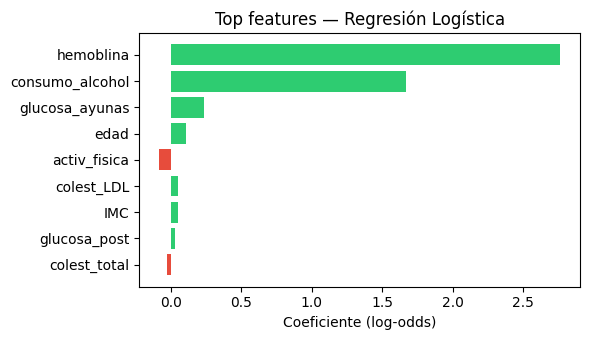

Conclusión:
  • Las features que más aumentan la probabilidad estimada son: hemoblina (coef=2.761), consumo_alcohol (coef=1.670), glucosa_ayunas (coef=0.233).
  • Las features que más reducen la probabilidad estimada son: activ_fisica (coef=-0.082), activ_fisica (coef=-0.058), colest_total (coef=-0.029).
  • Nota: los coeficientes están en unidades de log-odds; el signo indica dirección del efecto.


In [ ]:
# Top-N coeficientes de la Regresión Logística
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TOP_N = 10  # ajustable si quiero ver más/menos

# Recuperar clasificador (soporta Pipeline o estimador directo)
clf = model_Logistic
if hasattr(model_Logistic, 'named_steps'):
    clf = model_Logistic.named_steps.get('classifier', model_Logistic)

if not hasattr(clf, 'coef_'):
    print("El modelo no expone coeficientes (no es un regresor lineal o no entrenado).")
else:
    coeffs = clf.coef_.flatten()

    # Intentar obtener nombres desde el preprocesador ajustado; fallback a X.columns
    feature_names = None
    try:
        if hasattr(model_Logistic, 'named_steps') and 'preprocessor' in model_Logistic.named_steps:
            pre = model_Logistic.named_steps['preprocessor']
            feature_names = pre.get_feature_names_out()
        elif 'preprocessor' in globals() and hasattr(preprocessor, 'get_feature_names_out'):
            feature_names = preprocessor.get_feature_names_out()
    except Exception:
        feature_names = None

    if feature_names is None or len(feature_names) != len(coeffs):
        # Fallback: usar nombres originales de X si están disponibles
        try:
            feature_names = [str(c) for c in list(X.columns)]
        except Exception:
            feature_names = [f'feature_{i}' for i in range(len(coeffs))]

    # Mapear tokens numéricos a columnas originales cuando sea posible
    try:
        orig_cols = list(X.columns)
        resolved = []
        for name in feature_names:
            s = str(name).strip()
            if s.isdigit():
                idx = int(s)
                resolved.append(orig_cols[idx] if idx < len(orig_cols) else f'col_{s}')
            else:
                resolved.append(name)
        feature_names = resolved
    except Exception:
        feature_names = [str(n) for n in feature_names]

    df_coef = pd.DataFrame({'feature': feature_names, 'coef': coeffs})
    df_coef['abs_coef'] = df_coef['coef'].abs()
    df_top = df_coef.sort_values('abs_coef', ascending=False).head(TOP_N).reset_index(drop=True)

    # Mostrar tabla compacta
    print(f"Top {len(df_top)} features (por |coef|):")
    display(df_top[['feature','coef']])

    # Gráfico compacto
    try:
        plt.figure(figsize=(6, max(2, len(df_top)*0.35)))
        bars = plt.barh(df_top['feature'][::-1], df_top['coef'][::-1], color=['#2ecc71' if v>0 else '#e74c3c' for v in df_top['coef'][::-1]])
        plt.xlabel('Coeficiente (log-odds)')
        plt.title('Top features — Regresión Logística')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"No se pudo generar gráfico compacto: {e}")

    # Conclusión basada en el top-N
    pos = df_top[df_top['coef'] > 0].head(3)
    neg = df_top[df_top['coef'] < 0].head(3)

    concl_lines = []
    concl_lines.append("Conclusión:")
    if not pos.empty:
        pos_list = ", ".join([f"{r.feature} (coef={r.coef:.3f})" for r in pos.itertuples(index=False)])
        concl_lines.append(f"  • Las features que más aumentan la probabilidad estimada son: {pos_list}.")
    if not neg.empty:
        neg_list = ", ".join([f"{r.feature} (coef={r.coef:.3f})" for r in neg.itertuples(index=False)])
        concl_lines.append(f"  • Las features que más reducen la probabilidad estimada son: {neg_list}.")

    concl_lines.append("  • Nota: los coeficientes están en unidades de log-odds; el signo indica dirección del efecto.")

    print("\n".join(concl_lines))

    # Devolver data frame para uso posterior
    df_top_final = df_top.copy()
    df_top_final.index = np.arange(1, len(df_top_final)+1)
    df_top_final

## <span style="color:#800080;">6. Serialización y Producción </span>

**Como punto adicional, se ha generado el joblib y se realizó el deploy en producción con el modelo Gradient Boosting. Para su Verificación se puede realizar desde el siguiente link:**

https://pecd-supervisado-ctrl2.streamlit.app/

In [26]:
import os
import time
import joblib
import json
import platform
import sklearn
import pandas as pd
from sklearn.metrics import roc_auc_score

# ========================================
# MÉTODO 2: JOBLIB (Estándar ML) - Parcheado (guardar Regresión Logística)
# ========================================
joblib_path = '../app/models/model_joblib.joblib'
# Asegurar que exista el directorio
os.makedirs(os.path.dirname(joblib_path), exist_ok=True)

# Seleccionar el modelo a guardar (Regresión Logística como modelo de producción)
model_to_save = globals().get('model_Logistic', globals().get('model_GB_optimizado', globals().get('model_Gradient', None)))
if model_to_save is None:
    raise RuntimeError('No se encontró modelo a guardar (buscando `model_Logistic`, `model_GB_optimizado` o `model_Gradient`).')

# Calcular AUC sobre el test set (recalcular localmente para evitar dependencias de ejecución)
# Si el modelo es un pipeline que contiene preprocessor, predict_proba aceptará X_test crudo
auc = roc_auc_score(y_test, model_to_save.predict_proba(X_test)[:, 1])

# Guardar CON metadatos (buena práctica)
artifact = {
    'model': model_to_save,
    'feature_names': X.columns.tolist() if hasattr(X, 'columns') else None,
    'target_col': TARGET_COL,
    'auc_test': float(auc),
    'training_date': pd.Timestamp.now().isoformat(),
    'python_version': platform.python_version(),
    'sklearn_version': sklearn.__version__
}

start = time.time()
joblib.dump(artifact, joblib_path, compress=3)  # compress=3 es buen balance
joblib_save_time = time.time() - start

# Cargar y verificar
start = time.time()
loaded_artifact = joblib.load(joblib_path)
joblib_load_time = time.time() - start

model_joblib = loaded_artifact.get('model', None)
if model_joblib is None:
    raise RuntimeError('El artifact cargado no contiene la clave "model"')

# Verificar predicciones
pred_joblib = model_joblib.predict_proba(X_test)[:, 1]
auc_joblib = roc_auc_score(y_test, pred_joblib)

joblib_size = os.path.getsize(joblib_path) / 1024

print(f"📁 Archivo: {joblib_path}")
print(f"📦 Tamaño: {joblib_size:.2f} KB (comprimido)")
print(f"⏱️ Tiempo guardar: {joblib_save_time*1000:.2f} ms")
print(f"⏱️ Tiempo cargar: {joblib_load_time*1000:.2f} ms")
print(f"✅ AUC verificado: {auc_joblib:.4f}")
print(f"\n📋 Metadatos guardados: {list(loaded_artifact.keys())}")

📁 Archivo: ../app/models/model_joblib.joblib
📦 Tamaño: 4.92 KB (comprimido)
⏱️ Tiempo guardar: 24.74 ms
⏱️ Tiempo cargar: 22.21 ms
✅ AUC verificado: 0.9338

📋 Metadatos guardados: ['model', 'feature_names', 'target_col', 'auc_test', 'training_date', 'python_version', 'sklearn_version']


In [27]:
import os
import json
import platform
import sklearn
from sklearn.metrics import roc_auc_score
import pandas as pd

# ========================================
# MÉTODO 5B: JSON + Metadatos (Para APIs) - Parcheado (metadata para Regresión Logística)
# ========================================
json_path = '../app/models/model_metadata.json'
os.makedirs(os.path.dirname(json_path), exist_ok=True)

# Seleccionar modelo para calcular métricas (preferir Regresión Logística)
model_for_meta = globals().get('model_Logistic', globals().get('model_GB_optimizado', globals().get('model_Gradient', None)))
if model_for_meta is None:
    raise RuntimeError('No se encontró modelo para extraer metadatos (buscando `model_Logistic`, `model_GB_optimizado` o `model_Gradient`).')

# Calcular AUC de forma explícita aquí para evitar dependencias de orden de ejecución
auc = roc_auc_score(y_test, model_for_meta.predict_proba(X_test)[:, 1])

joblib_path = '../app/models/model_joblib.joblib'
file_size_kb = None
if os.path.exists(joblib_path):
    file_size_kb = os.path.getsize(joblib_path) / 1024

# Guardar metadatos en JSON (legible por cualquier lenguaje)
metadata = {
    'model_type': 'Logistic Regression',
    'model_file': os.path.basename(joblib_path),
    'feature_names': X.columns.tolist() if hasattr(X, 'columns') else None,
    'n_features': len(X.columns.tolist()) if hasattr(X, 'columns') else None,
    'target_col': TARGET_COL,
    'metrics': {
        'auc_test': round(float(auc), 4),
        'n_train_samples': len(X_train) if 'X_train' in globals() else None,
        'n_test_samples': len(X_test) if 'X_test' in globals() else None,
        'model_file_kb': round(file_size_kb, 2) if file_size_kb is not None else None
    },
    'training_info': {
        'date': pd.Timestamp.now().isoformat(),
        'python_version': platform.python_version(),
        'sklearn_version': sklearn.__version__
    }
}

with open(json_path, 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"📁 Metadatos guardados: {json_path}")
print(f"\n📋 Contenido (primera 1000 chars):")
print(json.dumps(metadata, indent=2, ensure_ascii=False)[:1000] + "...")

📁 Metadatos guardados: ../app/models/model_metadata.json

📋 Contenido (primera 1000 chars):
{
  "model_type": "Logistic Regression",
  "model_file": "model_joblib.joblib",
  "feature_names": [
    "edad",
    "sexo",
    "grupo_etnico",
    "nivel_educ",
    "nivel_ingr",
    "estado_laboral",
    "consumo_tabaco",
    "consumo_alcohol",
    "activ_fisica",
    "calidad_dieta",
    "horas_sueño",
    "horas_pantalla",
    "antec_familiar",
    "hist_hipert",
    "hist_cardiov",
    "IMC",
    "IOA",
    "presion_sistol",
    "presion_diast",
    "frec_cardio",
    "colest_total",
    "colest_HDL",
    "colest_LDL",
    "trigliceridos",
    "glucosa_ayunas",
    "glucosa_post",
    "insulina",
    "hemoblina"
  ],
  "n_features": 28,
  "target_col": "diagnostico_diabetes",
  "metrics": {
    "auc_test": 0.9338,
    "n_train_samples": 80000,
    "n_test_samples": 20000,
    "model_file_kb": 4.92
  },
  "training_info": {
    "date": "2026-01-31T08:06:20.423417",
    "python_version": "3.

## 7. Conclusiones

- **Resumen de resultados:** Optuna aplicado a Gradient Boosting alcanzó la mejor AUC en validación cruzada (mejor CV AUC ≈ 0.9465) y un AUC de test alto (≈ 0.9431). La Regresión Logística mostró AUC ligeramente menor (≈ 0.9338) pero una recall superior en test (≈ 0.895), relevante para diagnóstico clínico.

- **Interpretación clínica y decisión de producción:** Aunque el GB optimizado mejora la AUC, **se elige la Regresión Logística como modelo para producción** por: mayor recall (minimiza falsos negativos), interpretabilidad clínica (coeficientes) y facilidad de despliegue/ auditoría.

Tener en cuenta lo siguiente:

  • Las features que más aumentan la probabilidad estimada son: hemoblina (coef=2.761), consumo_alcohol (coef=1.670), glucosa_ayunas (coef=0.233).

- **Por qué no se usa Deep Learning aquí:**
  - Los datos son tabulares y de tamaño moderado; modelos lineales o boosting suelen igualar o superar redes profundas en este escenario.
  - Interpretabilidad y trazabilidad clínica son críticas: los coeficientes de la RL permiten explicaciones directas a clínicos, requisito para adopción y auditoría.
  - Recursos y despliegue: Regresion Logistica exige menos cómputo para inferencia y es más fácil de integrar en sistemas clínicos con latencia y regulación limitada.
  - Riesgo de overfitting: redes profundas requieren más datos y cuidado regularizador; con nuestra muestra, su ventaja sería incierta.

- **Recomendaciones**
  - Desplegar la `Regresión Logística` con el preprocesador final y documentar versiones en el JSON/joblib generado.
  - Mantener el pipeline GB+Optuna como referencia para re-evaluación periódica si cambian los datos o prevalencia.

> Para finalizar:  Optuna+GB mejora AUC pero, por la necesidad clínica de altos recall, interpretabilidad y facilidad de despliegue, la Regresión Logística es la opción preferida para producción en este estudio.

## <span style="color:#800080;">8. Referencias </span>

El caso se ha tomado de kaggle:  

https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset

